# Import libraries and set configs

In [32]:
import sys
import os
import random
import warnings
import numpy as np
import pandas as pd
import requests
from os import environ
from datetime import datetime, timedelta
from tqdm.auto import tqdm

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.style as style
from dotenv import load_dotenv, find_dotenv

sys.path.append("..")
sys.path.append("../..")

# use matplotlib style
style.use("fivethirtyeight")

# here we load environment variables from .env, must be called before init. class
load_dotenv(find_dotenv('../.env'), verbose=True)

# Set environment variable
environ["ENV"] = "optimize"

tv_username = os.getenv("TV_USERNAME")
tv_password = os.getenv("TV_PASSWORD")

class CFG:
    # load new data from exchanges
    load = True
    # create dataset from zero
    create_dataset = True
    # update existing dataset
    update_dataset = True
    # TP and SL target ratio
    target_high_ratio = 1.05
    target_low_ratio = 0.95
    # last previous data point to collect for model training (value represents number of hours before signal point)
    last = 272
    # for how long time (in hours) we want to predict
    target_offset = 128
    # what trade types to use: buy, sell, both
    ttype = "both"
    patterns_to_filter = ["STOCH_RSI_Volume24"]
    # period to aggregate
    agg_periods = [24, 72]
    agg_funcs = [np.min, np.max, np.mean, np.median, np.std]

pd.set_option("display.max_columns", 500)
pd.set_option("display.max_rows", 500)

tqdm.pandas()

warnings.simplefilter(action="ignore", category=(FutureWarning, pd.errors.PerformanceWarning))

# Load data

In [33]:
from ml.utils.ticker_loader import TickerLoader
from config.config import ConfigFactory

pattern = ["STOCH", "RSI", "Volume24"]
test_mode = False

configs = ConfigFactory.factory(environ).configs
configs["Higher_TF_indicator_list"] = ["Trend", "MACD"]
configs["Timeframes"]["work_timeframe"] = "1h"
configs["Timeframes"]["higher_timeframe"] = "4h"

if CFG.load:
    loader = TickerLoader(pattern, test_mode, **configs)
    min_time = datetime.now().replace(microsecond=0, second=0, minute=0) - pd.to_timedelta(365 * 10, unit="D")
    loader.load(min_time)
    for ttype in ["buy", "sell"]:
        print(f"Collect {ttype} stat")
        loader.collect_statistics(ttype, opt_limit=100000)

error while signin
you are using nologin method, data you access may be limited
2026-06-09 10:34:16.430 | INFO     | bot.bot:save_opt_dataframes:702 - 
Load the datasets...
2026-06-09 10:34:16.431 | INFO     | bot.bot:mon_save_opt_dataframes:963 - ================================================================================
2026-06-09 10:34:16.431 | INFO     | bot.bot:mon_save_opt_dataframes:964 - ByBitPerpetual
2026-06-09 10:34:16.432 | INFO     | bot.bot:mon_save_opt_dataframes:969 - 0GUSDT
2026-06-09 10:34:17.362 | INFO     | bot.bot:mon_save_opt_dataframes:969 - 1000000BABYDOGEUSDT
2026-06-09 10:34:18.300 | INFO     | bot.bot:mon_save_opt_dataframes:969 - 1000000MOGUSDT
2026-06-09 10:34:19.235 | INFO     | bot.bot:mon_save_opt_dataframes:969 - 10000NEXUSDT
2026-06-09 10:34:20.140 | INFO     | bot.bot:mon_save_opt_dataframes:969 - 10000SATSUSDT
2026-06-09 10:34:21.252 | INFO     | bot.bot:mon_save_opt_dataframes:969 - 1000BONKUSDT
2026-06-09 10:34:22.211 | INFO     | bot.bot:mon_

Collect buy stat
Collect sell stat


# Test loaded data

### Remove ticker files and clean them from stat and train dataframes

- if they have a lot of missing or gappy data
- if only 1h or 4h ticker dataframe presents

In [34]:
import glob
from pathlib import Path

tickers_1h = glob.glob("data/tickers/*_1h.pkl")
max_gap_ratio = 0.01
tickers_to_remove = []

def ticker_name(path):                 # data/tickers/CKUSDTUSDT_1h.pkl -> CKUSDTUSDT
    return Path(path).stem[:-3]        # drop "_1h" / "_4h"

# drop ticker files with a lot of missing or gappy data
for ticker in tqdm(tickers_1h):
    df = pd.read_pickle(ticker)
    intervals = df["time"].diff()[1:] # drop leading NaT
    nunique = len(intervals.unique())
    if nunique > 1:
        gap_count = (intervals.astype("timedelta64[s]") != timedelta(hours=1)).sum()
        gap_ratio = gap_count / len(intervals)
        max_gap = intervals.max()
        if gap_ratio > max_gap_ratio or max_gap >= timedelta(hours=48):
            reasons = []
            if gap_ratio > max_gap_ratio:
                reasons.append(f"{gap_ratio * 100:.2f}% non-1h intervals (>{int(max_gap_ratio * 100)}%)")
            if max_gap >= timedelta(hours=48):
                reasons.append(f"max gap {max_gap} (>=48h)")
            print(f"REMOVE {ticker_name(ticker)}: gappy data -> {', '.join(reasons)}")
            os.remove(ticker)
            four_h = ticker[:-6] + "4h.pkl"
            if os.path.exists(four_h):
                os.remove(four_h)
            tickers_to_remove.append(ticker_name(ticker))


# drop *USDTUSDT* files and any unpaired 1h/4h orphans
all_files = glob.glob("data/tickers/*.pkl")
have_1h = {ticker_name(p) for p in all_files if p.endswith("_1h.pkl")}
have_4h = {ticker_name(p) for p in all_files if p.endswith("_4h.pkl")}

for p in all_files:
    name = ticker_name(p)
    if "USDTUSDT" in name:
        reason = "malformed name (contains USDTUSDT)"
    elif name not in have_1h:
        reason = "missing 1h file (orphan 4h)"
    elif name not in have_4h:
        reason = "missing 4h file (orphan 1h)"
    else:
        continue
    if os.path.exists(p):
        print(f"REMOVE {name}: {reason} -> {p}")
        os.remove(p)
        tickers_to_remove.append(name)

tickers_to_remove = list(set(tickers_to_remove))
print(f"\nTotal tickers flagged for removal: {len(tickers_to_remove)}")

# remove flagged tickers from the signal-stat and train datasets
for ttype in ["buy", "sell"]:
    if not tickers_to_remove:
        break

    stat_df = pd.read_pickle(f"data/signal_stat/{ttype}_stat_1h.pkl")
    train_df = pd.read_pickle(f"data/signal_stat/train_{ttype}_272.pkl")
    stat_before, train_before = len(stat_df), len(train_df)

    stat_df = stat_df[~stat_df["ticker"].isin(tickers_to_remove)].reset_index(drop=True)
    train_df = train_df[~train_df["ticker"].isin(tickers_to_remove)].reset_index(drop=True)

    print(
        f"{ttype}: stat_df {stat_before} -> {len(stat_df)} "
        f"(-{stat_before - len(stat_df)} rows), "
        f"train_df {train_before} -> {len(train_df)} "
        f"(-{train_before - len(train_df)} rows)"
    )

    stat_df.to_pickle(f"data/signal_stat/{ttype}_stat_1h.pkl")
    train_df.to_pickle(f"data/signal_stat/train_{ttype}_272.pkl")


  0%|          | 0/4089 [00:00<?, ?it/s]

 21%|██        | 851/4089 [00:00<00:02, 1093.78it/s]

REMOVE OPNUSDT: gappy data -> 3.95% non-1h intervals (>1%)
REMOVE NIGHTUSDT: gappy data -> 3.95% non-1h intervals (>1%)


 40%|████      | 1652/4089 [00:01<00:02, 1098.08it/s]

REMOVE FOLKSUSDT: gappy data -> 3.95% non-1h intervals (>1%)
REMOVE POWERUSDT: gappy data -> 3.95% non-1h intervals (>1%)
REMOVE EDGEUSDT: gappy data -> 3.95% non-1h intervals (>1%)
REMOVE CFGUSDT: gappy data -> 3.95% non-1h intervals (>1%)


...

REMOVE UAIUSDT: gappy data -> 3.95% non-1h intervals (>1%)


 94%|█████████▎| 3825/4089 [00:03<00:00, 1064.21it/s]

REMOVE PUMPBTCUSDT: gappy data -> 3.95% non-1h intervals (>1%)
REMOVE TRUSTUSDT: gappy data -> 3.95% non-1h intervals (>1%)


100%|██████████| 4089/4089 [00:03<00:00, 1042.03it/s]


REMOVE BLUAIUSDT: gappy data -> 3.95% non-1h intervals (>1%)
REMOVE GHSTUSDT: missing 1h file (orphan 4h) -> data/tickers/GHSTUSDT_4h.pkl
REMOVE FORTHUSDT: missing 1h file (orphan 4h) -> data/tickers/FORTHUSDT_4h.pkl
REMOVE A2ZUSDT: missing 1h file (orphan 4h) -> data/tickers/A2ZUSDT_4h.pkl
REMOVE CKUSDTUSDT: malformed name (contains USDTUSDT) -> data/tickers/CKUSDTUSDT_1h.pkl
REMOVE IDEXUSDT: missing 1h file (orphan 4h) -> data/tickers/IDEXUSDT_4h.pkl
REMOVE ACAUSDT: missing 1h file (orphan 4h) -> data/tickers/ACAUSDT_4h.pkl
REMOVE DATAUSDT: missing 1h file (orphan 4h) -> data/tickers/DATAUSDT_4h.pkl
REMOVE UTKUSDT: missing 1h file (orphan 4h) -> data/tickers/UTKUSDT_4h.pkl
REMOVE OXTUSDT: missing 1h file (orphan 4h) -> data/tickers/OXTUSDT_4h.pkl
REMOVE MDTUSDT: missing 1h file (orphan 4h) -> data/tickers/MDTUSDT_4h.pkl
REMOVE FUNUSDT: missing 1h file (orphan 4h) -> data/tickers/FUNUSDT_4h.pkl
REMOVE WANUSDT: missing 1h file (orphan 4h) -> data/tickers/WANUSDT_4h.pkl
REMOVE RDNTUSDT:

### Plot time vs index for some of dataframe files

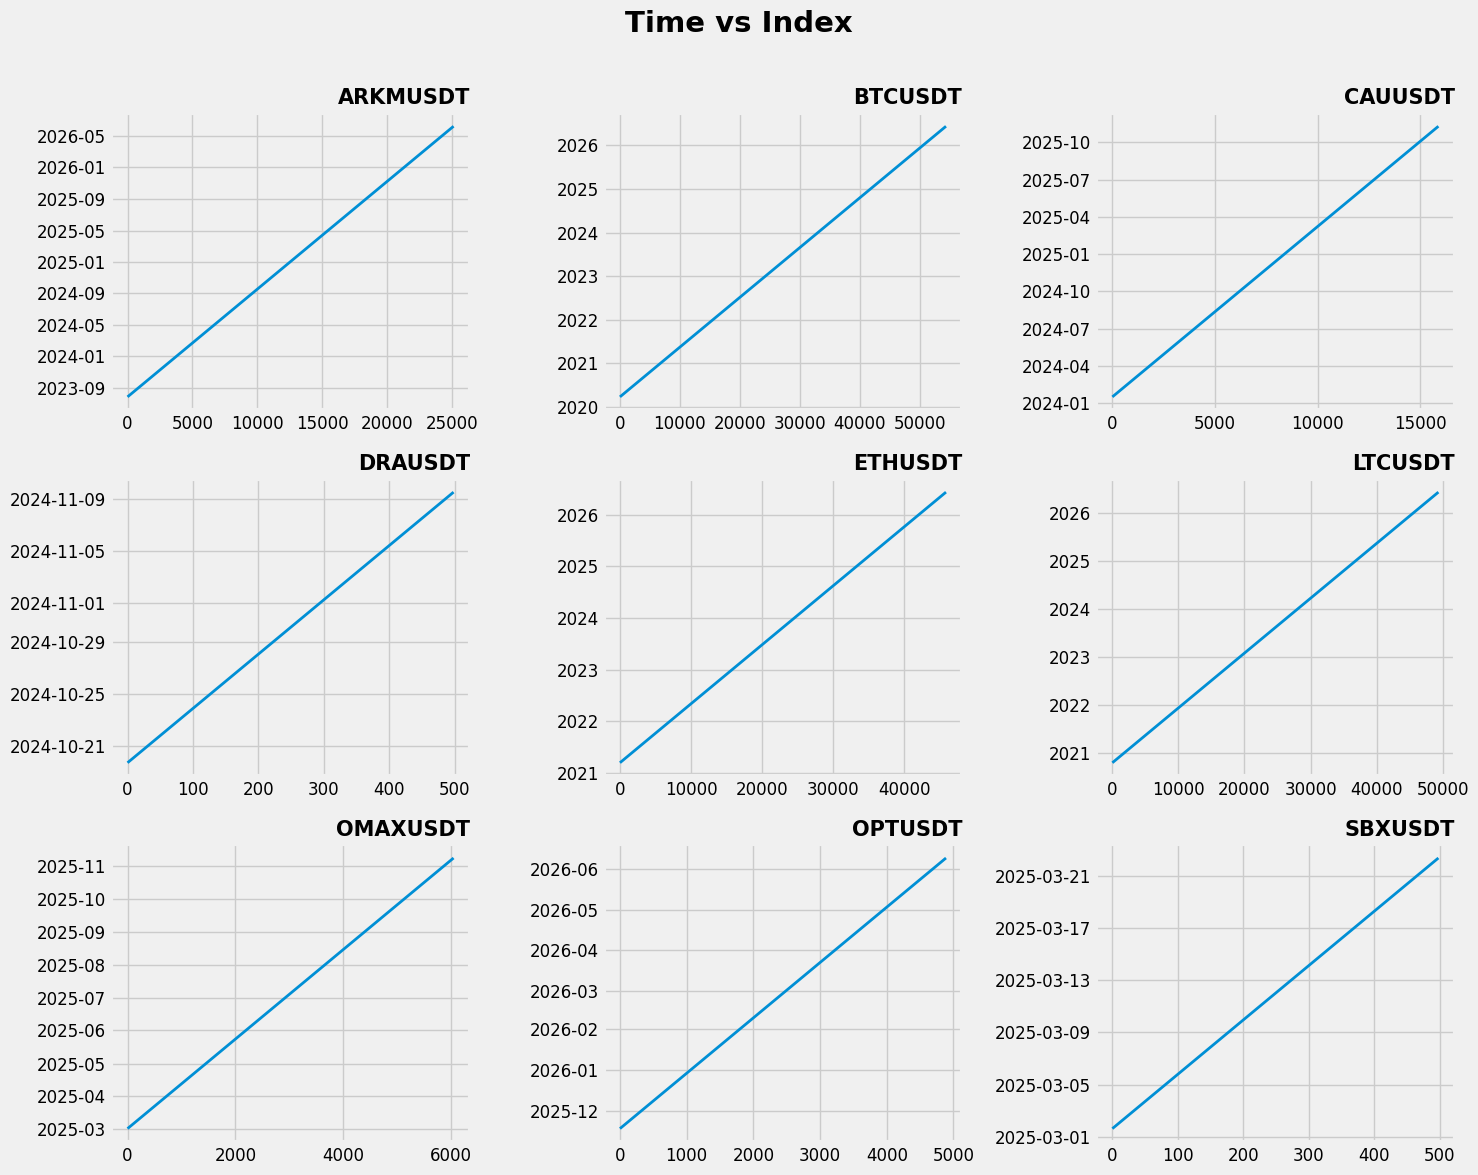

In [35]:
%matplotlib inline

n_cols = 3
n_rows = 3
figsize = (15, 4 * n_rows)

tickers = glob.glob("data/tickers/*_1h.pkl")
random_tickers = random.choices(tickers, k=n_cols*n_rows)
random_tickers[:3] = [t for t in tickers if "/BTCUSDT_1h" in t or "/ETHUSDT_1h" in t or "/LTCUSDT_1h" in t]

def plot_times(random_tickers, n_rows, n_cols):
    fig = plt.figure(figsize=figsize)
    
    for idx in range(n_cols*n_rows):
        ax = plt.subplot(n_rows, n_cols, idx + 1)
        
        df = pd.read_pickle(random_tickers[idx])
        sns.lineplot(data=df["time"])

        ax.set_ylabel("")
        plt.yticks(fontsize=12) 
        ax.set_xlabel("")
        plt.xticks(fontsize=12)
        # ax.spines["right"].set_visible(False)
        ax.set_title(f"{random_tickers[idx].split('/')[-1][:-7]}", loc="right", weight="bold", fontsize=15)
        ax.lines[0].set_linewidth(2)

    
    fig.suptitle("Time vs Index\n", ha="center",  fontweight="bold", fontsize=21)
    # fig.legend([1, 0], loc="upper center", bbox_to_anchor=(0.5, 0.96), fontsize=21, ncol=3)
    plt.tight_layout()
    plt.show()
    
plot_times(sorted(random_tickers),  n_rows=n_rows, n_cols=n_cols) 

### Backup all important data files before continue

In [36]:
import shutil

src = Path("data/signal_stat")
dst = src / "backup"
dst.mkdir(exist_ok=True)

for f in src.iterdir():
    if f.is_file():
        shutil.copy2(f, dst / f.name)

### Remove tickers that are in signal stat datasets but corresponding files are missing

# Prepare train data

### Create auxilary datasets

In [ ]:
from api.tvdatafeed.main import TvDatafeed, Interval
from utils.data_utils import (
    btcd_cols,
    btcdom_cols,
    create_train_df,
    fng_cols,
    get_file,
)


if CFG.create_dataset:
    # Get BTC dominance
    tv = TvDatafeed(username=tv_username, password=tv_password)

    btcd_new = tv.get_hist("BTC.D","CRYPTOCAP", interval=Interval.in_daily, n_bars=7000, extended_session=True).reset_index()
    btcd_new = btcd_new.drop(columns="symbol")
    btcd_new.columns = btcd_cols
    
    mask = btcd_new["time"].dt.hour == 4
    btcd_new.loc[mask, "time"] = btcd_new.loc[mask, "time"] - pd.to_timedelta(1, unit="h")

    btcd_path = "data/context/btcd.csv"
    if os.path.exists(btcd_path):
        btcd_prev = pd.read_csv(btcd_path, parse_dates=["time"])
        btcd = pd.concat([btcd_prev, btcd_new]).drop_duplicates("time").sort_values("time").reset_index(drop=True)
    else:
        btcd = btcd_new
    btcd.iloc[:-1].to_csv(btcd_path, index=False)
    btcd_new["time"] = btcd_new["time"] + pd.to_timedelta(23, unit="h")

    btcdom_new = tv.get_hist("BTCDOMUSDT.P","BINANCE", interval=Interval.in_4_hour, n_bars=7000, extended_session=True).reset_index()
    btcdom_new = btcdom_new.drop(columns="symbol")
    btcdom_new.columns = btcdom_cols
    
    btcdom_path = "data/context/btcdom.csv"
    if os.path.exists(btcdom_path):
        btcdom_prev = pd.read_csv(btcdom_path, parse_dates=["time"])
        btcdom = pd.concat([btcdom_prev, btcdom_new]).drop_duplicates("time").sort_values("time").reset_index(drop=True)
    else:
        btcdom = btcdom_new
    btcdom.iloc[:-1].to_csv(btcdom_path, index=False)
    btcdom_new["time"] = btcdom_new["time"] + pd.to_timedelta(3, unit="h")

    # Get Fear & Greed index
    fng_resp = requests.get("https://api.alternative.me/fng/?limit=0&format=json", timeout=30)
    fng_new = pd.DataFrame(fng_resp.json()["data"])
    fng_new["time"] = pd.to_datetime(fng_new["timestamp"].astype(int), unit="s") + pd.to_timedelta(3, unit="h")
    fng_new["fng_value"] = fng_new["value"].astype(int)
    fng_new = fng_new[fng_cols].sort_values("time").reset_index(drop=True)

    fng_path = "data/context/fng.csv"
    if os.path.exists(fng_path):
        fng_prev = pd.read_csv(fng_path, parse_dates=["time"])
        fng = pd.concat([fng_prev, fng_new]).drop_duplicates("time").sort_values("time").reset_index(drop=True)
    else:
        fng = fng_new
    fng.to_csv(fng_path, index=False)

    # first previous data point to collect for model training (value represents number of hours before signal point)
    first = 4
    # step of previous data points collecting (total number of points to collect is (last - first + step) / step)
    step = 4

    # Buy
    # good hours: 
    # dataset with the signal statistics
    buy_stat_df = pd.read_pickle("data/signal_stat/buy_stat_1h.pkl")
    buy_stat_df = buy_stat_df[buy_stat_df["time"].dt.year > 1970]
    buy_stat_df = buy_stat_df[buy_stat_df["pattern"].isin(CFG.patterns_to_filter)]

    # if previously generated dataset exists - update it, don't create it from scratch
    train_df_prev = None
    if CFG.update_dataset:
        try:
            train_df_prev = pd.read_pickle(f"data/signal_stat/train_buy_{CFG.last}.pkl")
        except FileNotFoundError:
            pass

    # dataset for model training
    train_buy = create_train_df(
        buy_stat_df, 
        btcd, 
        btcdom, 
        fng, 
        "buy", 
        configs, 
        CFG.target_offset, 
        first, 
        CFG.last, 
        step,
        CFG.target_high_ratio,
        CFG.target_low_ratio,
        train_df_prev,
        )
    
    nan_counts = train_buy.isnull().sum()
    if nan_counts.any():
        print("NaNs per column (train_buy):\n", nan_counts[nan_counts > 0])
    train_buy = train_buy.dropna()
    if CFG.update_dataset and train_df_prev is not None:
        train_buy = pd.concat([train_df_prev, train_buy]).reset_index(drop=True)
    train_buy.to_pickle(f"data/signal_stat/train_buy_{CFG.last}.pkl")

    display(train_buy.head())
    display(train_buy.shape)

    # Sell
    # good hours 
    # dataset with the signal statistics
    sell_stat_df = pd.read_pickle("data/signal_stat/sell_stat_1h.pkl")
    sell_stat_df = sell_stat_df[sell_stat_df["time"].dt.year > 1970]
    sell_stat_df = sell_stat_df[sell_stat_df["pattern"].isin(CFG.patterns_to_filter)]

    # if previously generated dataset exists - update it, don't create it from scratch
    train_df_prev = None
    if CFG.update_dataset:
        try:
            train_df_prev = pd.read_pickle(f"data/signal_stat/train_sell_{CFG.last}.pkl")
        except FileNotFoundError:
            pass
    # dataset for model training
    train_sell = create_train_df(
        sell_stat_df, 
        btcd, 
        btcdom, 
        fng, 
        "sell", 
        configs, 
        CFG.target_offset, 
        first, 
        CFG.last, 
        step,
        CFG.target_high_ratio,
        CFG.target_low_ratio,
        train_df_prev
        )
    
    nan_counts = train_sell.isnull().sum()
    if nan_counts.any():
        print("NaNs per column (train_sell):\n", nan_counts[nan_counts > 0])
    train_sell = train_sell.dropna()
    if CFG.update_dataset and train_df_prev is not None:
        train_sell = pd.concat([train_df_prev, train_sell]).reset_index(drop=True)
    train_sell.to_pickle(f"data/signal_stat/train_sell_{CFG.last}.pkl")

    display(train_sell.head())
    display(train_sell.shape)
    
    # this is made for tests
    test_df_buy_1 = buy_stat_df[buy_stat_df["time"].dt.hour == 0]
    test_df_buy_1 = create_train_df(
        test_df_buy_1, 
        btcd, 
        btcdom, 
        fng, 
        "buy", 
        configs, 
        CFG.target_offset, 
        first, 
        CFG.last, 
        step,
        CFG.target_high_ratio,
        CFG.target_low_ratio,
        )
    test_df_buy_1 = test_df_buy_1.dropna().sort_values("time").reset_index(drop=True)
    
    test_df_sell_1 = sell_stat_df[sell_stat_df["time"].dt.hour == 0]
    test_df_sell_1 = create_train_df(
        test_df_sell_1, 
        btcd, 
        btcdom, 
        fng, 
        "sell", 
        configs, 
        CFG.target_offset, 
        first, 
        CFG.last, 
        step,
        CFG.target_high_ratio,
        CFG.target_low_ratio,
        )
    test_df_sell_1 = test_df_sell_1.dropna().sort_values("time").reset_index(drop=True)

error while signin
you are using nologin method, data you access may be limited
100%|██████████| 1406/1406 [03:44<00:00,  6.28it/s]


NaNs per column (train_buy):
 funding_rate               51
macd                       72
macdsignal                 72
macdhist                   72
linear_reg                114
                         ... 
btcdom_open_prev_272      148
btcdom_high_prev_272      148
btcdom_low_prev_272       148
btcdom_close_prev_272     148
btcdom_volume_prev_272    148
Length: 1377, dtype: int64


,time,open,high,low,close,volume,funding_rate,rsi,stoch_slowk,stoch_slowd,stoch_diff,atr,cci,sar,macd,macdsignal,macdhist,linear_reg,linear_reg_angle,btcd_open,btcd_high,btcd_low,btcd_close,btcd_volume,btcdom_open,btcdom_high,btcdom_low,btcdom_close,btcdom_volume,high_prev_4,low_prev_4,close_prev_4,volume_prev_4,rsi_prev_4,stoch_slowk_prev_4,stoch_slowd_prev_4,stoch_diff_prev_4,atr_prev_4,cci_prev_4,sar_prev_4,macd_prev_4,macdsignal_prev_4,macdhist_prev_4,linear_reg_prev_4,linear_reg_angle_prev_4,btcdom_open_prev_4,btcdom_high_prev_4,btcdom_low_prev_4,btcdom_close_prev_4,btcdom_volume_prev_4,high_prev_8,low_prev_8,close_prev_8,volume_prev_8,funding_rate_prev_8,rsi_prev_8,stoch_slowk_prev_8,stoch_slowd_prev_8,stoch_diff_prev_8,atr_prev_8,cci_prev_8,sar_prev_8,macd_prev_8,macdsignal_prev_8,macdhist_prev_8,linear_reg_prev_8,linear_reg_angle_prev_8,btcdom_open_prev_8,btcdom_high_prev_8,btcdom_low_prev_8,btcdom_close_prev_8,btcdom_volume_prev_8,high_prev_12,low_prev_12,close_prev_12,volume_prev_12,rsi_prev_12,stoch_slowk_prev_12,stoch_slowd_prev_12,stoch_diff_prev_12,atr_prev_12,cci_prev_12,sar_prev_12,macd_prev_12,macdsignal_prev_12,macdhist_prev_12,linear_reg_prev_12,linear_reg_angle_prev_12,btcdom_open_prev_12,btcdom_high_prev_12,btcdom_low_prev_12,btcdom_close_prev_12,btcdom_volume_prev_12,high_prev_16,low_prev_16,close_prev_16,volume_prev_16,funding_rate_prev_16,rsi_prev_16,stoch_slowk_prev_16,stoch_slowd_prev_16,stoch_diff_prev_16,atr_prev_16,cci_prev_16,sar_prev_16,macd_prev_16,macdsignal_prev_16,macdhist_prev_16,linear_reg_prev_16,linear_reg_angle_prev_16,btcdom_open_prev_16,btcdom_high_prev_16,btcdom_low_prev_16,btcdom_close_prev_16,btcdom_volume_prev_16,high_prev_20,low_prev_20,close_prev_20,volume_prev_20,rsi_prev_20,stoch_slowk_prev_20,stoch_slowd_prev_20,stoch_diff_prev_20,atr_prev_20,cci_prev_20,sar_prev_20,macd_prev_20,macdsignal_prev_20,macdhist_prev_20,linear_reg_prev_20,linear_reg_angle_prev_20,btcdom_open_prev_20,btcdom_high_prev_20,btcdom_low_prev_20,btcdom_close_prev_20,btcdom_volume_prev_20,open_prev_24,high_prev_24,low_prev_24,close_prev_24,volume_prev_24,funding_rate_prev_24,rsi_prev_24,stoch_slowk_prev_24,stoch_slowd_prev_24,stoch_diff_prev_24,atr_prev_24,cci_prev_24,sar_prev_24,macd_prev_24,macdsignal_prev_24,macdhist_prev_24,linear_reg_prev_24,linear_reg_angle_prev_24,btcd_open_prev_24,btcd_high_prev_24,btcd_low_prev_24,btcd_close_prev_24,btcd_volume_prev_24,btcdom_open_prev_24,btcdom_high_prev_24,btcdom_low_prev_24,btcdom_close_prev_24,btcdom_volume_prev_24,high_prev_28,low_prev_28,close_prev_28,volume_prev_28,rsi_prev_28,stoch_slowk_prev_28,stoch_slowd_prev_28,stoch_diff_prev_28,atr_prev_28,cci_prev_28,sar_prev_28,macd_prev_28,macdsignal_prev_28,macdhist_prev_28,linear_reg_prev_28,linear_reg_angle_prev_28,btcdom_open_prev_28,btcdom_high_prev_28,btcdom_low_prev_28,btcdom_close_prev_28,btcdom_volume_prev_28,high_prev_32,low_prev_32,close_prev_32,volume_prev_32,funding_rate_prev_32,rsi_prev_32,stoch_slowk_prev_32,stoch_slowd_prev_32,stoch_diff_prev_32,atr_prev_32,cci_prev_32,sar_prev_32,macd_prev_32,macdsignal_prev_32,macdhist_prev_32,linear_reg_prev_32,linear_reg_angle_prev_32,btcdom_open_prev_32,btcdom_high_prev_32,btcdom_low_prev_32,btcdom_close_prev_32,btcdom_volume_prev_32,high_prev_36,low_prev_36,close_prev_36,volume_prev_36,rsi_prev_36,stoch_slowk_prev_36,stoch_slowd_prev_36,stoch_diff_prev_36,atr_prev_36,cci_prev_36,sar_prev_36,macd_prev_36,macdsignal_prev_36,macdhist_prev_36,linear_reg_prev_36,linear_reg_angle_prev_36,btcdom_open_prev_36,btcdom_high_prev_36,btcdom_low_prev_36,btcdom_close_prev_36,btcdom_volume_prev_36,high_prev_40,low_prev_40,close_prev_40,volume_prev_40,funding_rate_prev_40,rsi_prev_40,stoch_slowk_prev_40,stoch_slowd_prev_40,stoch_diff_prev_40,atr_prev_40,cci_prev_40,sar_prev_40,macd_prev_40,macdsignal_prev_40,macdhist_prev_40,linear_reg_prev_40,linear_reg_angle_prev_40,btcdom_open_prev_40,btcdom_high_prev_40,btcdom_low_prev_40,btcdom_close_prev_40,btcdom_volume_prev_40,...,btcdo

(63483, 1578)

 25%|██▌       | 339/1334 [00:35<01:18, 12.68it/s]

### Create train dataset

In [ ]:
train_buy = pd.read_pickle(f"data/signal_stat/train_buy_{CFG.last}.pkl")
train_sell = pd.read_pickle(f"data/signal_stat/train_sell_{CFG.last}.pkl")

train_df = pd.concat([train_buy, train_sell])
train_df = train_df.sort_values("time")

# do not consider the last signals - they may contain erroneus signals
train_df = train_df[train_df["time"] < train_df["time"].max()].reset_index(drop=True)

# all data for the last 90 days are test
test_date = train_df["time"].max() - pd.to_timedelta(90, unit="D")

# Data tests

### Sanity checks

In [ ]:
if CFG.create_dataset:
    full_df = pd.concat([train_buy, train_sell], ignore_index=True)

    # both trade types present (catches the train_df clobber bug)
    ttypes = set(full_df["ttype"].unique())
    assert ttypes == {"buy", "sell"}, f"expected both ttypes, got {ttypes}"

    # target is strictly binary
    targets = set(full_df["target"].unique())
    assert targets <= {0, 1}, f"unexpected target values: {targets}"

    # no NaNs survived the dropna()
    nan_cols = full_df.columns[full_df.isnull().any()].tolist()
    assert not nan_cols, f"NaNs present in columns: {nan_cols}"

    # no duplicate signals
    dup_mask = full_df.duplicated(subset=["ticker", "time", "ttype"])
    assert not dup_mask.any(), f"{dup_mask.sum()} duplicate (ticker, time, ttype) rows"

    # buy and sell are internally consistent with their ttype label
    assert (train_buy["ttype"] == "buy").all(), "train_buy contains non-buy rows"
    assert (train_sell["ttype"] == "sell").all(), "train_sell contains non-sell rows"

    # time is parseable datetime and within a sane range
    assert pd.api.types.is_datetime64_any_dtype(full_df["time"]), "time is not datetime"
    assert full_df["time"].dt.year.min() > 1970, "found epoch/placeholder timestamps"
    assert full_df["time"].max() <= pd.Timestamp.now(), "future timestamps present"

    # Fear & Greed index sanity: present, expected daily lags, and within 0-100
    fng_cols = [c for c in full_df.columns if c.startswith("fng_value")]
    assert "fng_value" in fng_cols, "fng_value column is missing"

    fng_lags = sorted(int(c.rsplit("_", 1)[-1]) for c in fng_cols if c != "fng_value")
    assert fng_lags == list(range(24, 265, 24)), f"unexpected fng lag set: {fng_lags}"

    # the index is bounded to [0, 100] by definition
    fng_min, fng_max = full_df[fng_cols].min().min(), full_df[fng_cols].max().max()
    assert 0 <= fng_min and fng_max <= 100, f"fng values out of [0, 100]: {fng_min}-{fng_max}"

    # the index publishes whole numbers; the daily ffill should preserve that
    assert (full_df[fng_cols] % 1 == 0).all().all(), "fng values are not whole numbers"

    # class balance sanity (just a heads-up, not a hard failure)
    class_1_ratio = full_df["target"].mean()
    print(f"class 1 ratio: {class_1_ratio:.4f}  "
          f"(buy={train_buy['target'].mean():.4f}, sell={train_sell['target'].mean():.4f})")

    print(f"rows: buy={len(train_buy)}, sell={len(train_sell)}, total={len(full_df)}")
    print("All train dataset sanity tests passed.")

class 1 ratio: 0.5198  (buy=0.5342, sell=0.5019)
rows: buy=63310, sell=50699, total=114009
All train dataset sanity tests passed.


### Test train dataframe columns

100%|██████████| 114003/114003 [00:11<00:00, 10046.87it/s]


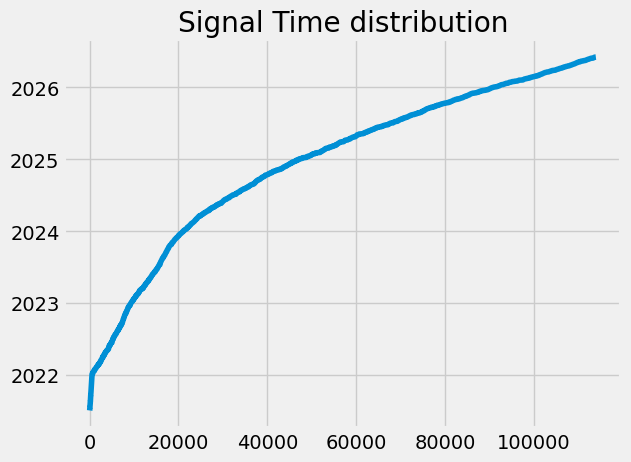

In [ ]:
import re

price_cols = ["open", "high", "low", "close"]
higher_features = ["time", "linear_reg", "linear_reg_angle", "macd", "macdhist", "macdsignal"]
funding_cols = ["funding_rate"]
rsi_stoch_cols = ["rsi", "stoch_diff", "stoch_slowd", "stoch_slowk"]

if CFG.create_dataset:
    # check if train dataset has only columns that we expect
    cols = set(re.sub(r"_prev_\d+", "", c) for c in train_buy.columns)

    agg_funcs = ["amin", "amax", "mean", "median", "std"]
    agg_cols = [c for c in cols if len(c.split("_")) > 2 and c.split("_")[-2] in agg_funcs]

    expected_cols = set(price_cols + higher_features + funding_cols + rsi_stoch_cols +
                        btcd_cols + btcdom_cols + agg_cols + ["atr", "cci", "sar", "volume", "fng_value", "pattern", "target", "max_price_deviation",
                                                              "min_price_deviation", "ticker", "ttype", "close_time", "first_price", "last_price"])
    assert expected_cols == cols

    # check RSI and STOCH columns, their values must be in [0, 100] range 
    rsi_stoch_cols_ = [c for c in train_df.columns if ("rsi" in c or "stoch" in c) and "diff" not in c]
    for r_s_c in rsi_stoch_cols_:
        assert train_df[r_s_c].min() > -0.0001
        assert train_df[r_s_c].max() < 100.0001

    # check volume columns, their values must be >= 0
    vol_cols_ = [c for c in train_df.columns if "volume" in c]
    for v_c in vol_cols_:
        assert train_df[v_c].min() >= 0

    # check funding columns, their period must be 8 hours
    funding_cols_ = [c for c in train_df.columns if c.startswith("funding")]
    for f_c in funding_cols_:
        num = "".join([i for i in f_c if i.isdigit()])
        if len(num) > 0:
            num = int(num)
            assert num % 8 == 0

    # check BTC dominance columns, their values must be in [0, 100] range 
    # and their period must be 24 hours
    btcd_cols_ = [c for c in train_df.columns if c.startswith("btcd_") and "volume" not in c]
    for b_c in btcd_cols_:
        pass_cycle = False
        for a_c in agg_funcs:
            if a_c in b_c:
                pass_cycle = True
                break
        if pass_cycle:
            continue
        # check values
        assert train_df[b_c].min() >= 0
        assert train_df[b_c].max() <= 100
        # check period
        num = "".join([i for i in b_c if i.isdigit()])
        if len(num) > 0:
            num = int(num)
            assert num % 24 == 0

    # check the rest columns, their period must be 4 hours
    rest_cols_ = [c for c in train_df.columns if c not in funding_cols_ and c not in btcd_cols_]
    for r_c in rest_cols_:
        num = "".join([i for i in r_c if i.isdigit()])
        if len(num) > 0:
            num = int(num)
            assert num % 4 == 0

    # check if changing of source dataframe doesn't affect the resulting train dataframe
    test_df_buy_2 = train_buy[train_buy["time"].dt.hour == 0]
    assert test_df_buy_1.shape == test_df_buy_2.shape
    test_df_sell_2 = train_sell[train_sell["time"].dt.hour == 0]
    assert test_df_sell_1.shape == test_df_sell_2.shape

    # check if columns that were added for backtest and statistics are correct
    for i, row in tqdm(train_df.iterrows(), total=len(train_df)):
        if row["last_price"] > 0:
            assert row["close_time"] - row["time"] == pd.to_timedelta(CFG.target_offset, unit="h")
            assert round(row["max_price_deviation"], 8) <= CFG.target_high_ratio - 1
        else:
            assert row["close_time"] - row["time"] <= pd.to_timedelta(CFG.target_offset, unit="h")
            if row["target"] == 1:
                assert round(row["max_price_deviation"], 8) >= CFG.target_high_ratio - 1
            else:
                assert round(row["max_price_deviation"], 8) < CFG.target_high_ratio - 1

    # plot time values 
    train_df["time"].plot(title="Signal Time distribution")

### Test target corectness

In [ ]:
if CFG.create_dataset:
    for ttype in ["buy", "sell"]:
        df = train_buy if ttype == "buy" else train_sell
        prev_ticker = None
        skip = False
        x = df[["ticker", "ttype", "pattern", "time", "close", "target"]]

        for i in tqdm(range(df.shape[0]), desc=ttype):
            row = x.iloc[i]
            pattern, ticker, time_, target = row["pattern"], row["ticker"], row["time"], row["target"]

            if ticker != prev_ticker:
                prev_ticker = ticker
                try:
                    tmp_df = pd.read_pickle(f"data/tickers/{ticker}_1h.pkl")
                except FileNotFoundError:
                    print(f"FileNotFoundError Error: {ticker}")
                    skip = True
                    continue
                else:
                    skip = False
            else:
                if skip:
                    continue

            tmp_df_1h = tmp_df.copy()
            try:
                idx = tmp_df_1h[tmp_df_1h["time"] == time_].index[0]
            except IndexError:
                print(f"Index Error: {ticker} at index {i}")
                continue

            close_price = tmp_df_1h.loc[tmp_df_1h["time"] == time_, "close"].values[0]
            last_idx = min(idx + CFG.target_offset, len(tmp_df_1h) - 1)
            last_price = tmp_df_1h.iloc[last_idx, tmp_df_1h.columns.get_loc("close")]

            high_price = close_price * CFG.target_high_ratio
            low_price = close_price * CFG.target_low_ratio
            tmp_df_1h["high_price"] = high_price
            tmp_df_1h["low_price"] = low_price
            tmp_df_1h = tmp_df_1h.iloc[idx + 1:idx + CFG.target_offset + 1][["time", "close", "high", "high_price", "low", "low_price"]]

            if ttype == "buy":
                tmp_df_1h["signal"] = tmp_df_1h["low"] < tmp_df_1h["low_price"]
                tmp_df_1h["anti_signal"] = tmp_df_1h["high"] > tmp_df_1h["high_price"]
                stoch_profitable = last_price < close_price
            else:
                tmp_df_1h["signal"] = tmp_df_1h["high"] > tmp_df_1h["high_price"]
                tmp_df_1h["anti_signal"] = tmp_df_1h["low"] < tmp_df_1h["low_price"]
                stoch_profitable = last_price > close_price

            first_signal = tmp_df_1h["signal"].argmax()
            first_anti_signal = tmp_df_1h["anti_signal"].argmax()

            try:
                if tmp_df_1h["signal"].max() == 0 and tmp_df_1h["anti_signal"].max() == 0:
                    if pattern.startswith("STOCH"):
                        if stoch_profitable:
                            assert target == 1
                        else:
                            assert target == 0
                elif tmp_df_1h["signal"].max() == 0:
                    assert target == 0
                elif tmp_df_1h["anti_signal"].max() == 0:
                    assert target == 1
                else:
                    if target == 1:
                        assert first_signal < first_anti_signal
                    else:
                        assert first_signal > first_anti_signal
            except AssertionError:
                print(f"AssertionError: ticker: {ticker} at index {i}")

sell: 100%|██████████| 50699/50699 [01:21<00:00, 623.23it/s]


### Find minimum acceptable class 1 / class 0 ratio considering singal statistics and our TP / SL ratio

In [ ]:
# if target = 1 but price didn't reach TP - what is percent of cases when it happenes and what is average positive price movement
tp_threshold = CFG.target_high_ratio - 1
sl_threshold = 1 - CFG.target_low_ratio

low_price_dev_num_1 = train_buy.query("target == 1 & max_price_deviation < @tp_threshold").shape[0]
normal_price_dev_num_1 = train_buy.query("target == 1").shape[0]
avg_low_price_dev_1 = train_buy.query("target == 1 & max_price_deviation < @tp_threshold")["max_price_deviation"].mean()
low_2_norm_ratio_1 = low_price_dev_num_1/normal_price_dev_num_1

# if target = 0 but price didn't reach SL - what is percent of cases when it happenes and what is average negative price movement
low_price_dev_num_0 = train_buy.query("target == 0 & min_price_deviation < @sl_threshold").shape[0]
normal_price_dev_num_0 = train_buy.query("target == 0").shape[0]
avg_low_price_dev_0 = train_buy.query("target == 0 & min_price_deviation < @sl_threshold")["min_price_deviation"].mean()
low_2_norm_ratio_0 = low_price_dev_num_0/normal_price_dev_num_0

for class_1_ratio in np.arange(0.51, 0, -0.001):
    expectation = ((CFG.target_high_ratio - 1) * (1 - low_2_norm_ratio_1) + avg_low_price_dev_1 * low_2_norm_ratio_1) * class_1_ratio -\
           ((1 - CFG.target_low_ratio) * (1 - low_2_norm_ratio_0) + avg_low_price_dev_0 * low_2_norm_ratio_0) * (1 - class_1_ratio)
    if expectation < 0:
        print(round(class_1_ratio + 0.001, 4))
        break

0.436


### Target distribution + look for profitable buy and sell hours using Trust Interval (TI)

In [ ]:
def q10(x):
    return x.quantile(0.1)

def q20(x):
    return x.quantile(0.2)

def q30(x):
    return x.quantile(0.3)

def q90(x):
    return x.quantile(0.9)

def trust_interval(row, z=1.95):
    """ Calculate trust interval for Bernulli distribution """
    sum_, val1 = row["total"], row["count"]
    val2 = sum_ - val1
    n = val1 + val2
    p = val1 / n
    low_bound = p - z * np.sqrt(p * (1-p) / n)
    high_bound = p + z * np.sqrt(p * (1-p) / n)
    return round(low_bound, 4), round(high_bound, 4)

# save only hours with low trust interval bound more than this bound
TI_low_bound = 0.495

profitable_hours_TI = {}

for ttype in ["buy", "sell"]:
    df = train_buy if ttype == "buy" else train_sell

    pvt = df[df["time"] < test_date]
    pvt = pvt[["target", "pattern", "time", "max_price_deviation"]]
    pvt["hour"] = pvt["time"].dt.hour
    pvt = pvt.pivot_table(
        index=["hour", "target"],
        values=["pattern", "max_price_deviation"],
        aggfunc={
            "pattern": "count",
            "max_price_deviation": ["median", q10, q20, q30, q90],
        },
    ).reset_index()
    pvt.columns = ["hour", "target", "max_price_dev_q50",
                   "max_price_dev_q10", "max_price_dev_q20",
                   "max_price_dev_q30", "max_price_dev_q90",
                   "pattern"]
    pvt["total"] = pvt.groupby("hour")["pattern"].transform("sum")
    pvt = pvt.rename(columns={"pattern": "count"})
    pvt["pct"] = pvt["count"] / pvt["total"]
    pvt = pvt[pvt["target"] == 1]
    pvt["trust_interval"] = pvt.apply(trust_interval, axis=1)

    print(ttype.capitalize())
    display(pvt)
    display(df["ttype"].value_counts())
    display(df[["target", "pattern"]].value_counts())
    display(df[["target", "pattern"]].value_counts(normalize=True))
    mask = pvt["trust_interval"].apply(lambda x: x[0]) >= TI_low_bound
    profitable_hours_TI[ttype] = pvt.loc[mask, "hour"].tolist()
    display(profitable_hours_TI[ttype])

profitable_buy_hours_TI = profitable_hours_TI["buy"]
profitable_sell_hours_TI = profitable_hours_TI["sell"]


Buy


,hour,target,max_price_dev_q50,max_price_dev_q10,max_price_dev_q20,max_price_dev_q30,max_price_dev_q90,count,total,pct,trust_interval
1,0,1,0.110657,0.056312,0.066732,0.078318,0.275978,1362,2584,0.527090,"(0.5079, 0.5462)"
3,1,1,0.115066,0.059354,0.071518,0.084416,0.252704,1691,2931,0.576936,"(0.5591, 0.5947)"
5,2,1,0.111225,0.056604,0.066526,0.079160,0.266049,1802,3254,0.553780,"(0.5368, 0.5708)"
7,3,1,0.121181,0.058141,0.069444,0.085375,0.282297,1996,3582,0.557231,"(0.541, 0.5734)"
9,4,1,0.118842,0.058840,0.073045,0.088607,0.304908,1999,3573,0.559474,"(0.5433, 0.5757)"
11,5,1,0.101257,0.056147,0.066778,0.075635,0.272573,1397,2611,0.535044,"(0.516, 0.5541)"
13,6,1,0.098696,0.056271,0.065289,0.074879,0.257671,1172,2219,0.528166,"(0.5075, 0.5488)"
15,7,1,0.095490,0.054377,0.062085,0.070172,0.242095,965,1830,0.527322,"(0.5046, 0.5501)"
17,8,1,0.113612,0.055778,0.067471,0.079516,0.285558,948,1875,0.505600,"(0.4831, 0.5281)"
19,9,1,0.123022,0.054097,0.065232,0.080284,0.334949,863,1699,0.507946,"(0.4843, 0.5316)"


ttype
buy    63310
Name: count, dtype: int64

target  pattern           
1       STOCH_RSI_Volume24    33818
0       STOCH_RSI_Volume24    29492
Name: count, dtype: int64

target  pattern           
1       STOCH_RSI_Volume24    0.534165
0       STOCH_RSI_Volume24    0.465835
Name: proportion, dtype: float64

...

,hour,target,max_price_dev_q50,max_price_dev_q10,max_price_dev_q20,max_price_dev_q30,max_price_dev_q90,count,total,pct,trust_interval
1,0,1,0.113046,0.055773,0.065005,0.076984,0.334636,653,1373,0.475601,"(0.4493, 0.5019)"
3,1,1,0.105738,0.053435,0.062163,0.075761,0.340498,789,1767,0.446520,"(0.4235, 0.4696)"
5,2,1,0.101373,0.052472,0.061600,0.071455,0.293661,1018,2187,0.465478,"(0.4447, 0.4863)"
7,3,1,0.104426,0.054190,0.064386,0.075294,0.323498,1323,2759,0.479522,"(0.461, 0.4981)"
9,4,1,0.105201,0.053545,0.064649,0.075359,0.326366,1387,2956,0.469215,"(0.4513, 0.4871)"
11,5,1,0.117281,0.057418,0.069468,0.081061,0.317585,1369,2803,0.488405,"(0.47, 0.5068)"
13,6,1,0.116953,0.055390,0.066237,0.080643,0.330018,1179,2332,0.505575,"(0.4854, 0.5258)"
15,7,1,0.124244,0.054444,0.068740,0.085377,0.357410,1223,2330,0.524893,"(0.5047, 0.5451)"
17,8,1,0.121294,0.056140,0.067777,0.082035,0.326515,1103,1980,0.557071,"(0.5353, 0.5788)"
19,9,1,0.116028,0.056103,0.067004,0.083350,0.310613,1171,2099,0.557885,"(0.5367, 0.579)"


ttype
sell    50699
Name: count, dtype: int64

target  pattern           
1       STOCH_RSI_Volume24    25447
0       STOCH_RSI_Volume24    25252
Name: count, dtype: int64

target  pattern           
1       STOCH_RSI_Volume24    0.501923
0       STOCH_RSI_Volume24    0.498077
Name: proportion, dtype: float64

[7, 8, 9, 15, 17]

### Visualize buy hours distribution

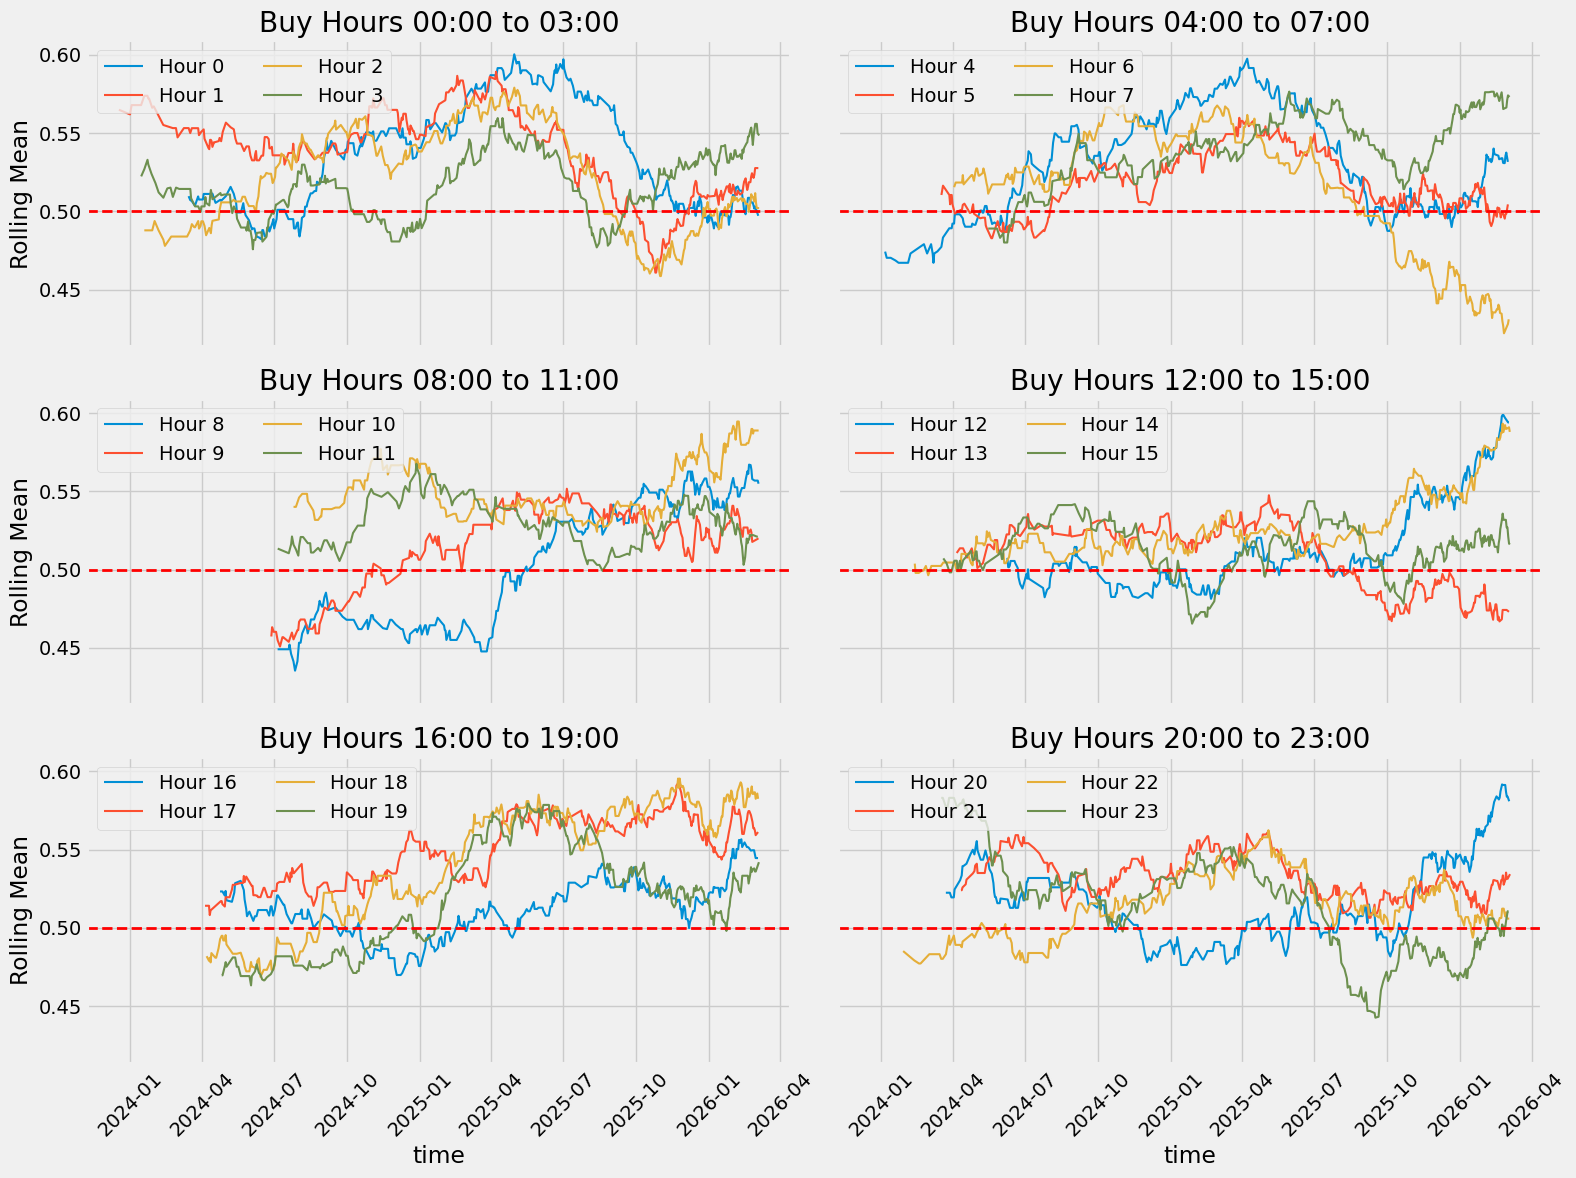

In [ ]:
# Pivot the data
pvt = train_buy.loc[(train_buy["time"] < test_date), ["time", "target"]]
pvt["hour"] = pvt["time"].dt.hour
pvt = pvt.pivot_table(
    index="time", columns="hour", values="target", aggfunc="mean"
)

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i in range(6):
    ax = axes[i]
    start_hour = i * 4
    end_hour = start_hour + 3

    # Plot each of the 4 hours designated for this subplot
    for hour in range(start_hour, end_hour + 1):
        if hour in pvt.columns:  # Check to ensure the hour exists in the data
            tmp = pvt[hour].dropna().rolling(window=168).mean()
            sns.lineplot(
                data=tmp, ax=ax, label=f"Hour {hour}", linewidth=1.5, legend="brief"
            )

    # Add the horizontal reference line to the current subplot
    ax.axhline(y=0.5, color="red", linestyle="--", linewidth=2)

    # Customize the current subplot
    ax.set_title(f"Buy Hours {start_hour:02d}:00 to {end_hour:02d}:00")
    ax.set_ylabel("Rolling Mean")
    ax.legend(loc="upper left", ncol=2)  # 2-column legend to save space
    ax.tick_params(axis="x", labelrotation=45)

# Adjust the layout to prevent titles/labels from overlapping
plt.tight_layout()
plt.show()

### Look for profitable buy hours using Rolling Mean (RM)

In [ ]:
results = []

for hour in range(24):
    if hour in pvt.columns:
        rolling_series = pvt[hour].dropna().rolling(window=168).mean()
        valid_rolling = rolling_series.dropna()

        if len(valid_rolling) > 0:
            pct_above = (valid_rolling > 0.5).mean() * 100
            pct_max = valid_rolling.max()
            pct_min = valid_rolling.min()
        else:
            pct_above = np.nan
            pct_max = np.nan
            pct_min = np.nan
    else:
        pct_above = np.nan
        pct_max = np.nan
        pct_min = np.nan

    results.append({
        "hour": hour, 
        "percent_above_0_5": pct_above, 
        "pct_min": pct_min,
        "pct_max": pct_max,
        })

# Create the final DataFrame
summary_buy_df = pd.DataFrame(results)

# Optional: Format the percentage to 2 decimal places for better readability
summary_buy_df[["percent_above_0_5", "pct_min", "pct_max"]] = summary_buy_df[["percent_above_0_5", "pct_min", "pct_max"]].round(2)

print(summary_buy_df.sort_values("percent_above_0_5", ascending=False))

    hour  percent_above_0_5  pct_min  pct_max
17    17             100.00     0.51     0.59
21    21             100.00     0.51     0.56
10    10             100.00     0.52     0.59
11    11              99.59     0.50     0.57
14    14              97.94     0.50     0.59
7      7              94.58     0.48     0.58
1      1              88.65     0.46     0.59
18    18              84.05     0.47     0.60
5      5              80.98     0.48     0.56
15    15              80.79     0.47     0.54
0      0              80.24     0.48     0.60
9      9              79.86     0.45     0.55
22    22              79.18     0.48     0.56
16    16              78.80     0.47     0.56
4      4              77.69     0.47     0.60
3      3              77.43     0.48     0.56
19    19              72.37     0.46     0.58
12    12              71.95     0.48     0.60
20    20              69.09     0.48     0.59
2      2              68.46     0.46     0.58
6      6              65.34     0.

### Visualize sell hours distribution

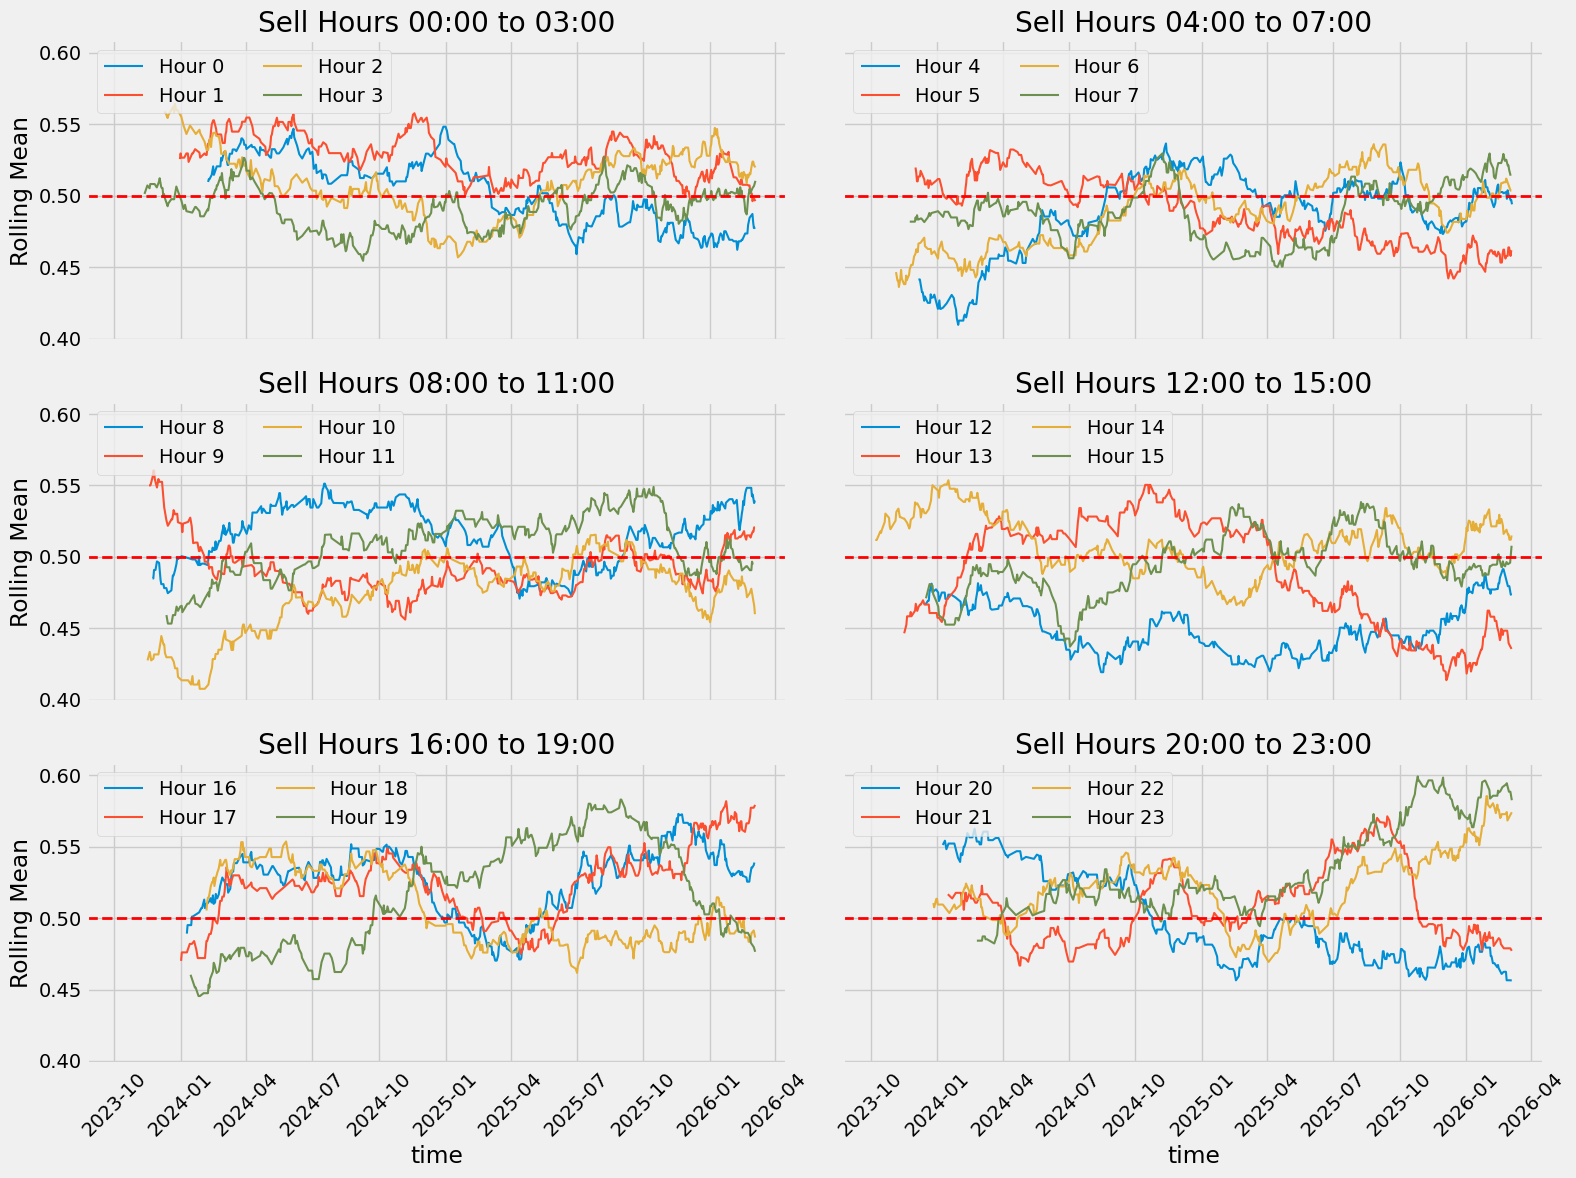

In [ ]:
# Pivot the data
pvt = train_sell.loc[(train_sell["time"] < test_date), ["time", "target"]]
pvt["hour"] = pvt["time"].dt.hour
pvt = pvt.pivot_table(
    index="time", columns="hour", values="target", aggfunc="mean"
)

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 12), sharex=True, sharey=True)
axes = axes.flatten()

# Loop through the 6 subplots
for i in range(6):
    ax = axes[i]
    start_hour = i * 4
    end_hour = start_hour + 3

    # Plot each of the 4 hours designated for this subplot
    for hour in range(start_hour, end_hour + 1):
        if hour in pvt.columns:  # Check to ensure the hour exists in the data
            tmp = pvt[hour].dropna().rolling(window=168).mean()
            sns.lineplot(
                data=tmp, ax=ax, label=f"Hour {hour}", linewidth=1.5, legend="brief"
            )

    # Add the horizontal reference line to the current subplot
    ax.axhline(y=0.5, color="red", linestyle="--", linewidth=2)

    # Customize the current subplot
    ax.set_title(f"Sell Hours {start_hour:02d}:00 to {end_hour:02d}:00")
    ax.set_ylabel("Rolling Mean")
    ax.legend(loc="upper left", ncol=2)  # 2-column legend to save space
    ax.tick_params(axis="x", labelrotation=45)

# Adjust the layout to prevent titles/labels from overlapping
plt.tight_layout()
plt.show()

### Look for profitable sell hours using Rolling Mean (RM)

In [ ]:
results = []

for hour in range(24):
    if hour in pvt.columns:
        rolling_series = pvt[hour].dropna().rolling(window=168).mean()
        valid_rolling = rolling_series.dropna()

        if len(valid_rolling) > 0:
            pct_above = (valid_rolling > 0.5).mean() * 100
            pct_max = valid_rolling.max()
            pct_min = valid_rolling.min()
        else:
            pct_above = np.nan
            pct_max = np.nan
            pct_min = np.nan
    else:
        pct_above = np.nan
        pct_max = np.nan
        pct_min = np.nan

    results.append({
        "hour": hour, 
        "percent_above_0_5": pct_above, 
        "pct_min": pct_min,
        "pct_max": pct_max,
        })

# Create the final DataFrame
summary_sell_df = pd.DataFrame(results)

# Optional: Format the percentage to 2 decimal places for better readability
summary_sell_df[["percent_above_0_5", "pct_min", "pct_max"]] = summary_sell_df[["percent_above_0_5", "pct_min", "pct_max"]].round(2)

print(summary_sell_df.sort_values("percent_above_0_5", ascending=False))

    hour  percent_above_0_5  pct_min  pct_max
1      1              98.03     0.50     0.56
23    23              94.08     0.48     0.60
16    16              83.50     0.47     0.57
22    22              82.29     0.47     0.59
17    17              81.15     0.47     0.58
8      8              72.16     0.47     0.55
2      2              71.23     0.46     0.56
14    14              70.26     0.47     0.55
19    19              64.79     0.45     0.58
11    11              64.52     0.45     0.55
21    21              53.73     0.47     0.57
0      0              47.08     0.46     0.55
4      4              43.45     0.41     0.54
18    18              43.24     0.46     0.55
13    13              42.08     0.41     0.55
15    15              39.39     0.44     0.54
6      6              37.03     0.44     0.54
3      3              34.62     0.45     0.53
20    20              33.72     0.46     0.56
5      5              31.23     0.44     0.53
7      7              29.60     0.

Let's select sell hours with avg profitable ratio >= 0.6 and intersect them with previously selected hours to sell

### Save profitable hours

In [ ]:
os.makedirs("data/context", exist_ok=True)

RM_percent_above_0_5 = 60

profitable_buy_hours_RM = summary_buy_df.query("percent_above_0_5 >= @RM_percent_above_0_5")["hour"].tolist()
# intersect profitable_hours with buy hours to save
profitable_buy_hours = sorted(list(set(profitable_buy_hours_RM).intersection(set(profitable_buy_hours_TI))))

profitable_sell_hours_RM = summary_sell_df.query("percent_above_0_5 >= @RM_percent_above_0_5")["hour"].tolist()
# intersect profitable_hours with sell hours to save
profitable_sell_hours = sorted(list(set(profitable_sell_hours_RM).intersection(set(profitable_sell_hours_TI))))


pkl_path = "data/context/profitable_hours.csv"
new_row = pd.DataFrame([{
    "time": datetime.now(),
    "test_date": test_date,
    "TI_low_bound": TI_low_bound,
    "RM_percent_above_0_5": RM_percent_above_0_5,
    "profitable_buy_hours_RM": profitable_buy_hours_RM,
    "profitable_buy_hours_TI": profitable_buy_hours_TI,
    "profitable_buy_hours": profitable_buy_hours,
    "profitable_sell_hours_RM": profitable_sell_hours_RM,
    "profitable_sell_hours_TI": profitable_sell_hours_TI,
    "profitable_sell_hours": profitable_sell_hours,
}])

if os.path.exists(pkl_path):
    profitable_hours_df = pd.read_csv(pkl_path)
    profitable_hours_df = pd.concat([profitable_hours_df, new_row], ignore_index=True)
else:
    profitable_hours_df = new_row

profitable_hours_df.to_csv(pkl_path, index=False)
profitable_hours_df[[c for c in profitable_hours_df.columns if c not in ["time"]]]

,test_date,TI_low_bound,RM_percent_above_0_5,profitable_buy_hours_RM,profitable_buy_hours_TI,profitable_buy_hours,profitable_sell_hours_RM,profitable_sell_hours_TI,profitable_sell_hours
0,2026-03-06 12:00:00,0.495,60,"[0, 1, 2, 3, 4, 6, 7, 10, 11, 12, 14, 15, 16, ...","[0, 1, 2, 3, 4, 5, 6, 7, 10, 11, 14, 15, 16, 1...","[0, 1, 2, 3, 4, 6, 7, 10, 11, 14, 15, 16, 17, ...","[1, 2, 8, 11, 14, 16, 17, 19, 21, 22, 23]","[8, 9, 13, 14, 15, 16, 17, 19]","[8, 14, 16, 17, 19]"
1,2026-03-06 12:00:00,0.495,60,"[0, 1, 2, 3, 4, 6, 7, 10, 11, 12, 14, 15, 16, ...","[0, 1, 2, 3, 4, 5, 6, 7, 10, 11, 14, 15, 16, 1...","[0, 1, 2, 3, 4, 6, 7, 10, 11, 14, 15, 16, 17, ...","[1, 2, 8, 11, 14, 16, 17, 19, 21, 22, 23]","[8, 9, 13, 15, 16, 17, 19]","[8, 16, 17, 19]"
2,2026-03-07 11:00:00,0.495,60,"[0, 1, 2, 3, 4, 6, 7, 10, 11, 12, 14, 15, 16, ...","[0, 1, 2, 3, 4, 5, 6, 7, 10, 11, 14, 15, 16, 1...","[0, 1, 2, 3, 4, 6, 7, 10, 11, 14, 15, 16, 17, ...","[1, 8, 17, 19, 22, 23]","[8, 9, 13, 15]",[8]
3,2026-03-07 11:00:00,0.495,60,"[0, 1, 2, 3, 4, 6, 7, 10, 11, 12, 14, 15, 16, ...","[0, 1, 2, 3, 4, 5, 6, 7, 10, 11, 14, 15, 16, 1...","[0, 1, 2, 3, 4, 6, 7, 10, 11, 14, 15, 16, 17, ...","[1, 8, 16, 17, 19, 22, 23]","[8, 9, 13, 15]",[8]
4,2026-03-08 07:00:00,0.495,60,"[0, 1, 2, 3, 4, 6, 7, 10, 11, 12, 14, 15, 16, ...","[0, 1, 2, 3, 4, 5, 6, 7, 10, 11, 14, 15, 16, 1...","[0, 1, 2, 3, 4, 6, 7, 10, 11, 14, 15, 16, 17, ...","[1, 8, 17, 19, 22, 23]","[8, 9, 13, 15]",[8]
5,2026-03-08 10:00:00,0.495,60,"[0, 1, 3, 4, 5, 7, 9, 10, 11, 12, 14, 15, 16, ...","[0, 1, 2, 3, 4, 5, 6, 7, 10, 14, 15, 16, 17, 1...","[0, 1, 3, 4, 5, 7, 10, 14, 15, 16, 17, 18, 19,...","[1, 2, 8, 11, 14, 16, 17, 19, 22, 23]","[7, 8, 9, 14, 15, 17]","[8, 14, 17]"
6,2026-03-08 10:00:00,0.495,60,"[0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 14, 15...","[0, 1, 2, 3, 4, 5, 6, 7, 10, 11, 14, 15, 16, 1...","[0, 1, 2, 3, 4, 5, 6, 7, 10, 11, 14, 15, 16, 1...","[1, 2, 8, 11, 14, 16, 17, 19, 22, 23]","[7, 8, 9, 15, 16, 17]","[8, 16, 17]"
7,2026-03-09 02:00:00,0.495,60,"[0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 14, 15...","[0, 1, 2, 3, 4, 5, 6, 7, 10, 11, 14, 15, 16, 1...","[0, 1, 2, 3, 4, 5, 6, 7, 10, 11, 14, 15, 16, 1...","[1, 2, 8, 11, 14, 16, 17, 19, 22, 23]","[7, 8, 9, 15, 17]","[8, 17]"
8,2026-03-09 02:00:00,0.495,60,"[0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 14, 15...","[0, 1, 2, 3, 4, 5, 6, 7, 10, 11, 14, 15, 16, 1...","[0, 1, 2, 3, 4, 5, 6, 7, 10, 11, 14, 15, 16, 1...","[1, 2, 8, 11, 14, 16, 17, 19, 22, 23]","[7, 8, 9, 15, 17]","[8, 17]"
9,2026-03-09 15:00:00,0.495,60,"[0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 14, 15...","[0, 1, 2, 3, 4, 5, 6, 7, 10, 11, 14, 15, 16, 1...","[0, 1, 2, 3, 4, 5, 6, 7, 10, 11, 14, 15, 16, 1...","[1, 2, 8, 11, 14, 16, 17, 19, 22, 23]","[7, 8, 9, 15, 17]","[8, 17]"


# Data visualization

### Plot ratio of class 1 for every week day

Monday = 0, Sunday = 6

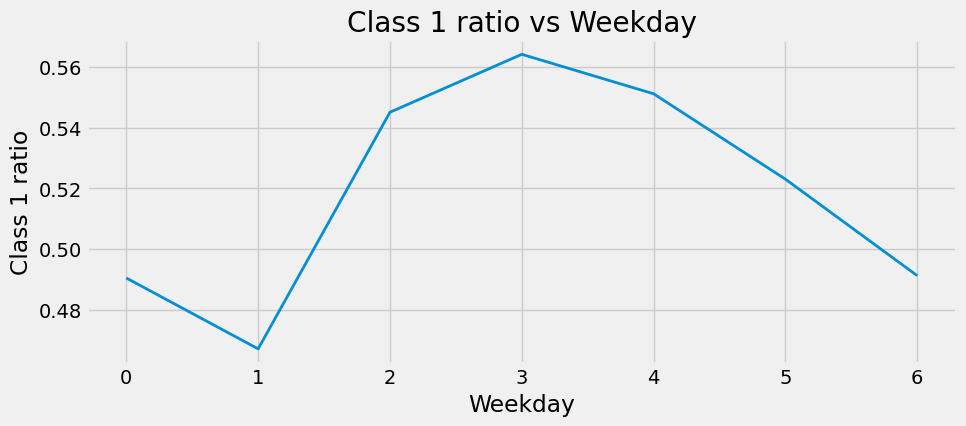

In [ ]:
plt.figure(figsize=(10, 4))

group_df = train_df[(train_df["time"].dt.year >= 2020)]
group_df["weekday"] = group_df["time"].dt.weekday
ax = group_df.groupby("weekday")["target"].mean().plot()
ax.lines[0].set_linewidth(2)
ax.set_xlabel("Weekday")
ax.set_ylabel("Class 1 ratio")
ax.set_title("Class 1 ratio vs Weekday");

### Plot ratio of class 1 for every month

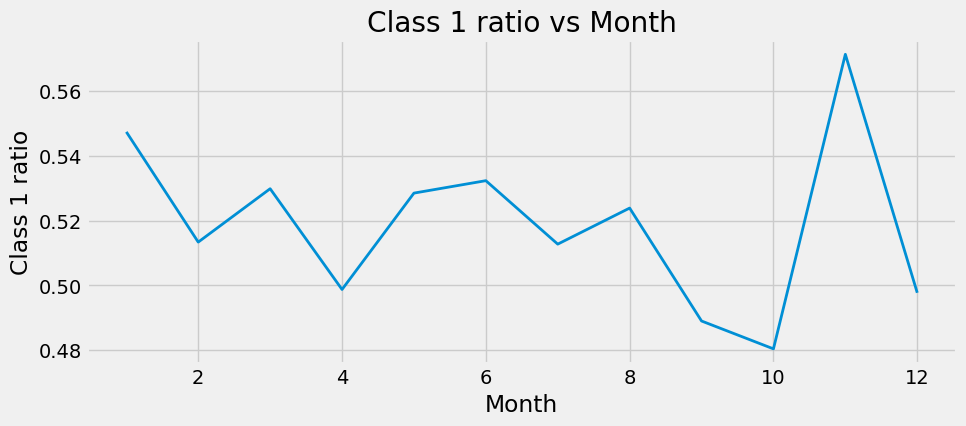

In [ ]:
plt.figure(figsize=(10, 4))

group_df = train_df[(train_df["time"].dt.year >= 2020)]
group_df["month"] = group_df["time"].dt.month
ax = group_df.groupby("month")["target"].mean().plot()
ax.lines[0].set_linewidth(2)
ax.set_xlabel("Month")
ax.set_ylabel("Class 1 ratio")
ax.set_title("Class 1 ratio vs Month");

### Visualize buy trades

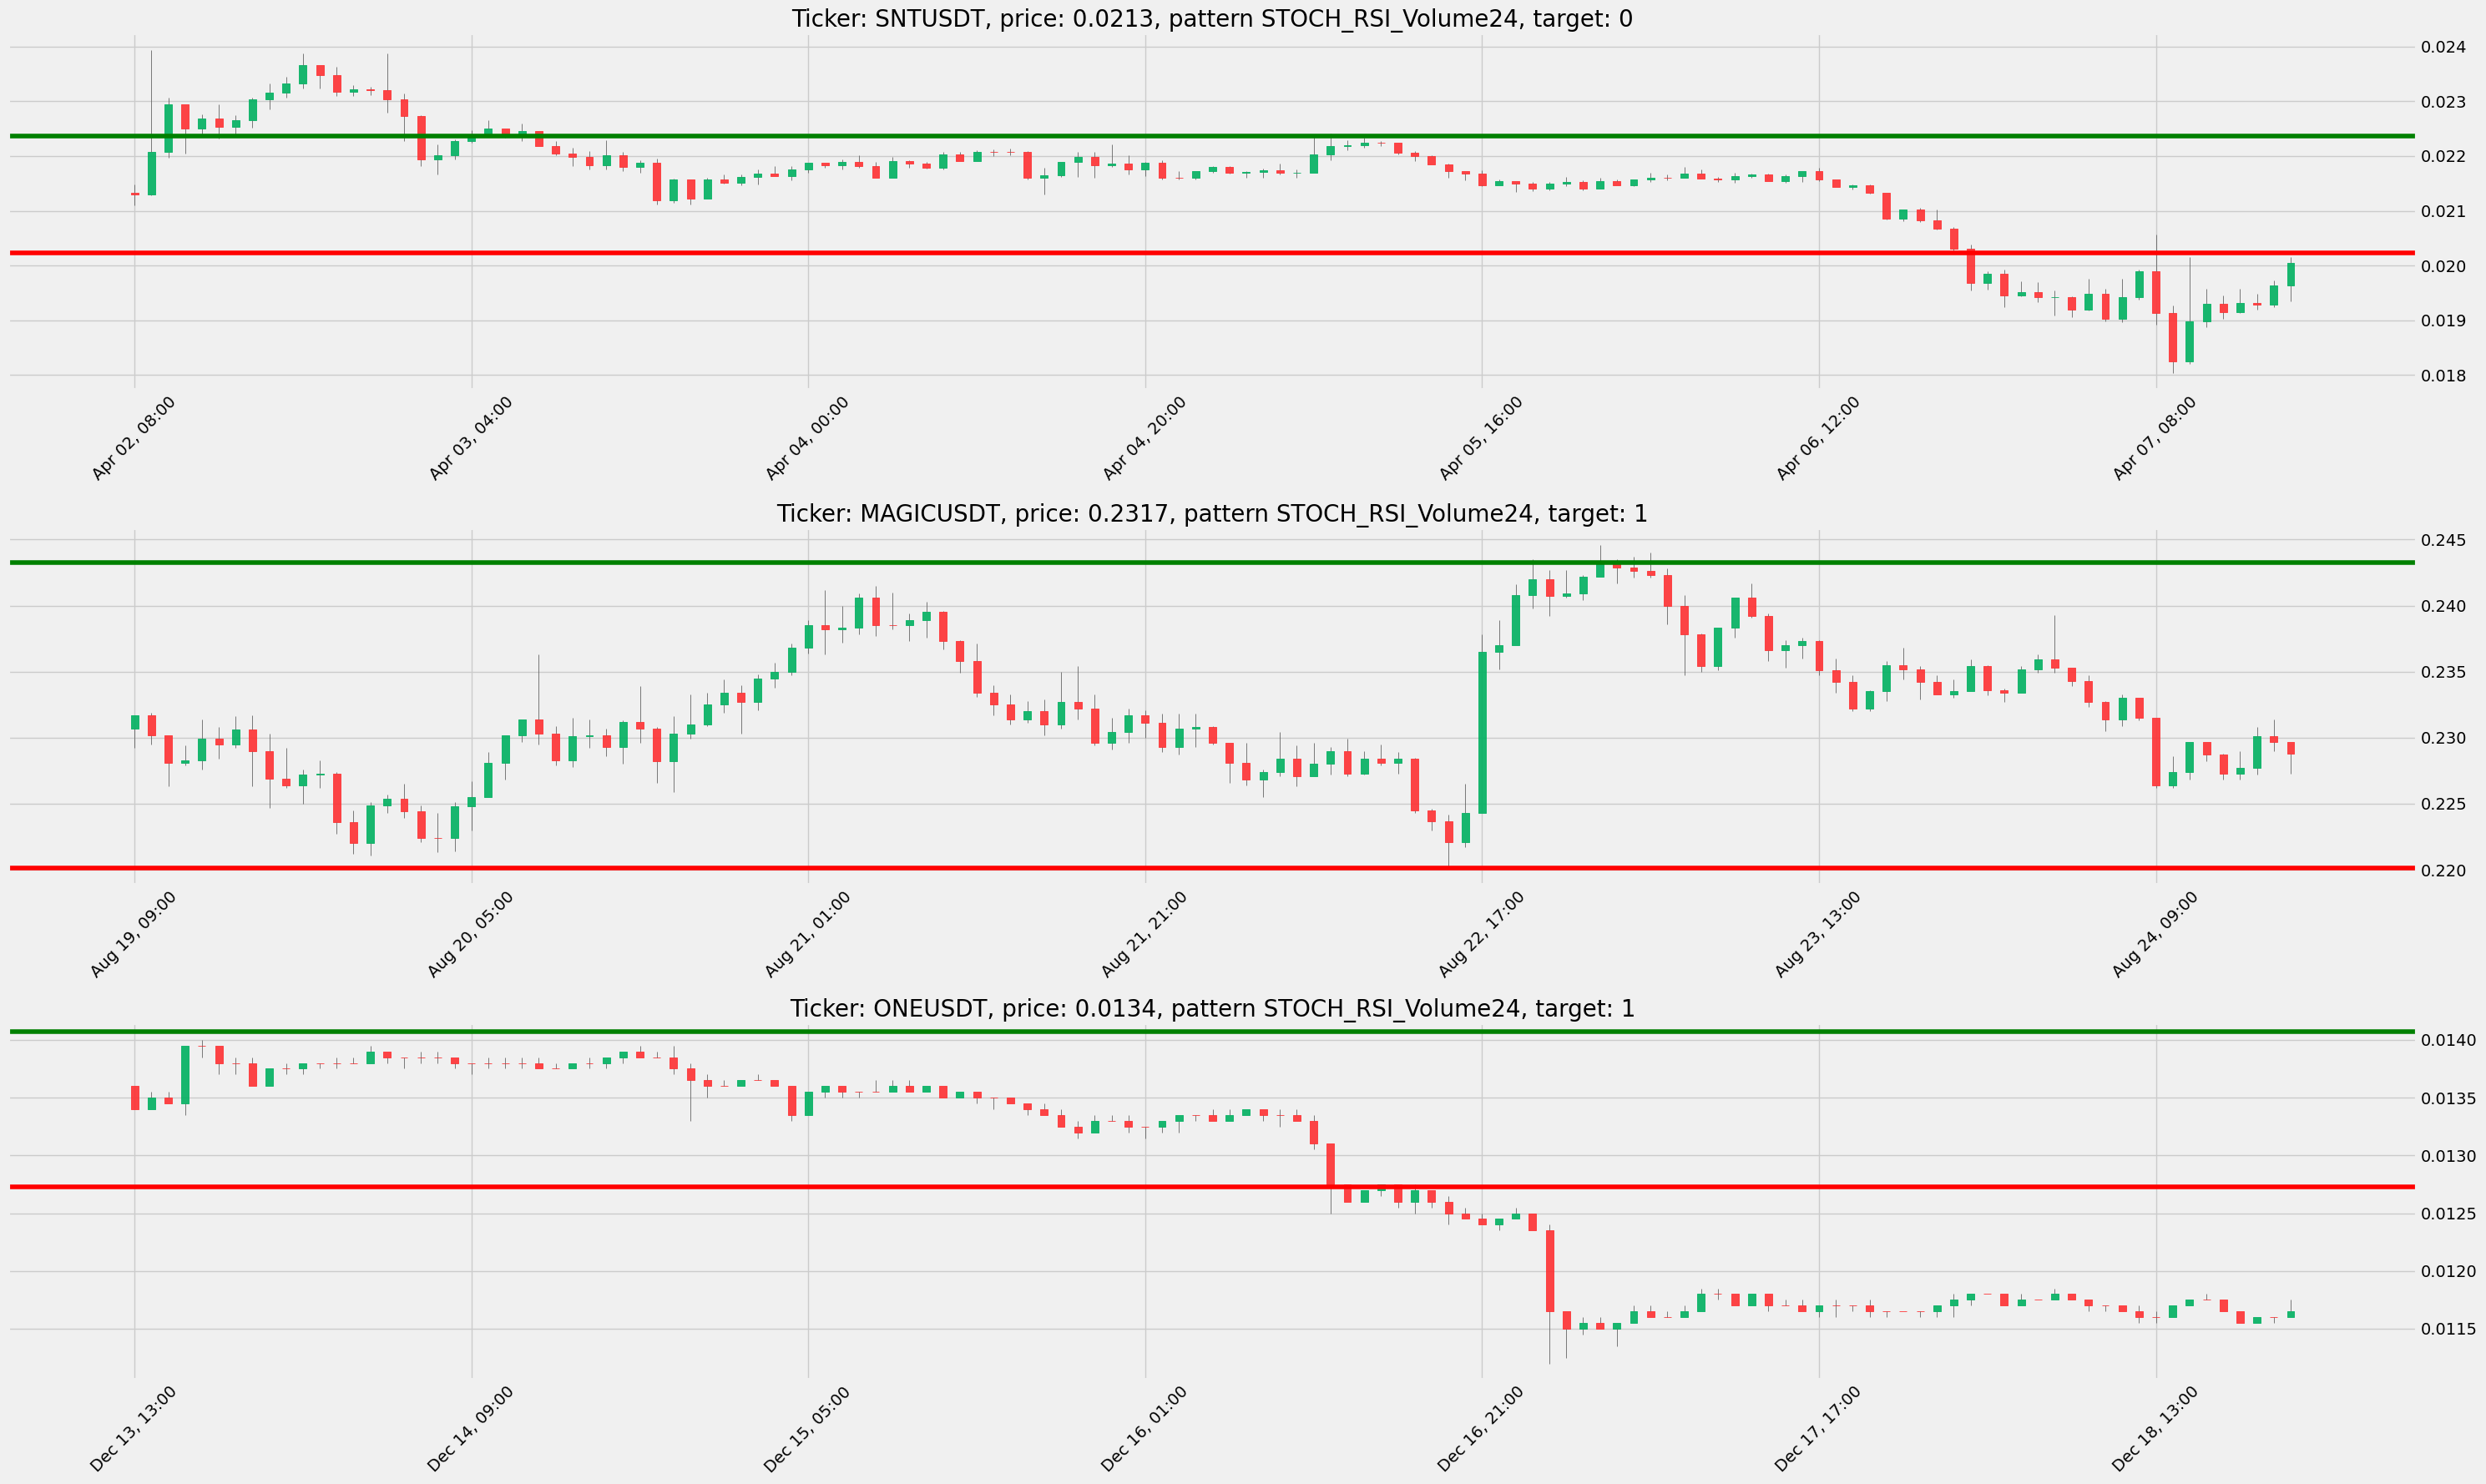

In [ ]:
import matplotlib.pyplot as plt
import mplfinance as mpf

if CFG.create_dataset:
    plt_num = 3
    j = 1
    fig = plt.figure(figsize=(30, 6 * plt_num))

    buy_idxs = train_buy.index
    test_buy = train_buy.sample(plt_num, axis=0)


    for i, row in test_buy.iterrows():
        ticker = row["ticker"]
        time = row["time"]
        target = row["target"]
        ttype = row["ttype"]
        pattern = row["pattern"]

        df_1h, _ = get_file(ticker)
        df_1h = df_1h[(df_1h["time"] >= time) & (df_1h["time"] <= time + timedelta(hours=CFG.target_offset))]

        ohlc = df_1h[["time", "open", "high", "low", "close", "volume"]].set_index("time")
        
        price = df_1h.iloc[0]["close"]
        high_price = price * CFG.target_high_ratio
        low_price = price * CFG.target_low_ratio

        ax = fig.add_subplot(plt_num, 1, j)
        mpf.plot(ohlc, type="candle", warn_too_much_data=1001, style="yahoo", ylabel="", tz_localize=True, ax=ax)
        
        if ttype == "buy":
            ax.axhline(high_price, color="g")
            ax.axhline(low_price, color="r")
        else:
            ax.axhline(high_price, color="r")
            ax.axhline(low_price, color="g")
        ax.set_title(f"Ticker: {ticker}, price: {price}, pattern {pattern}, target: {target}", fontsize=20)
        j += 1
        
    fig.tight_layout()

### Visualize sell trades

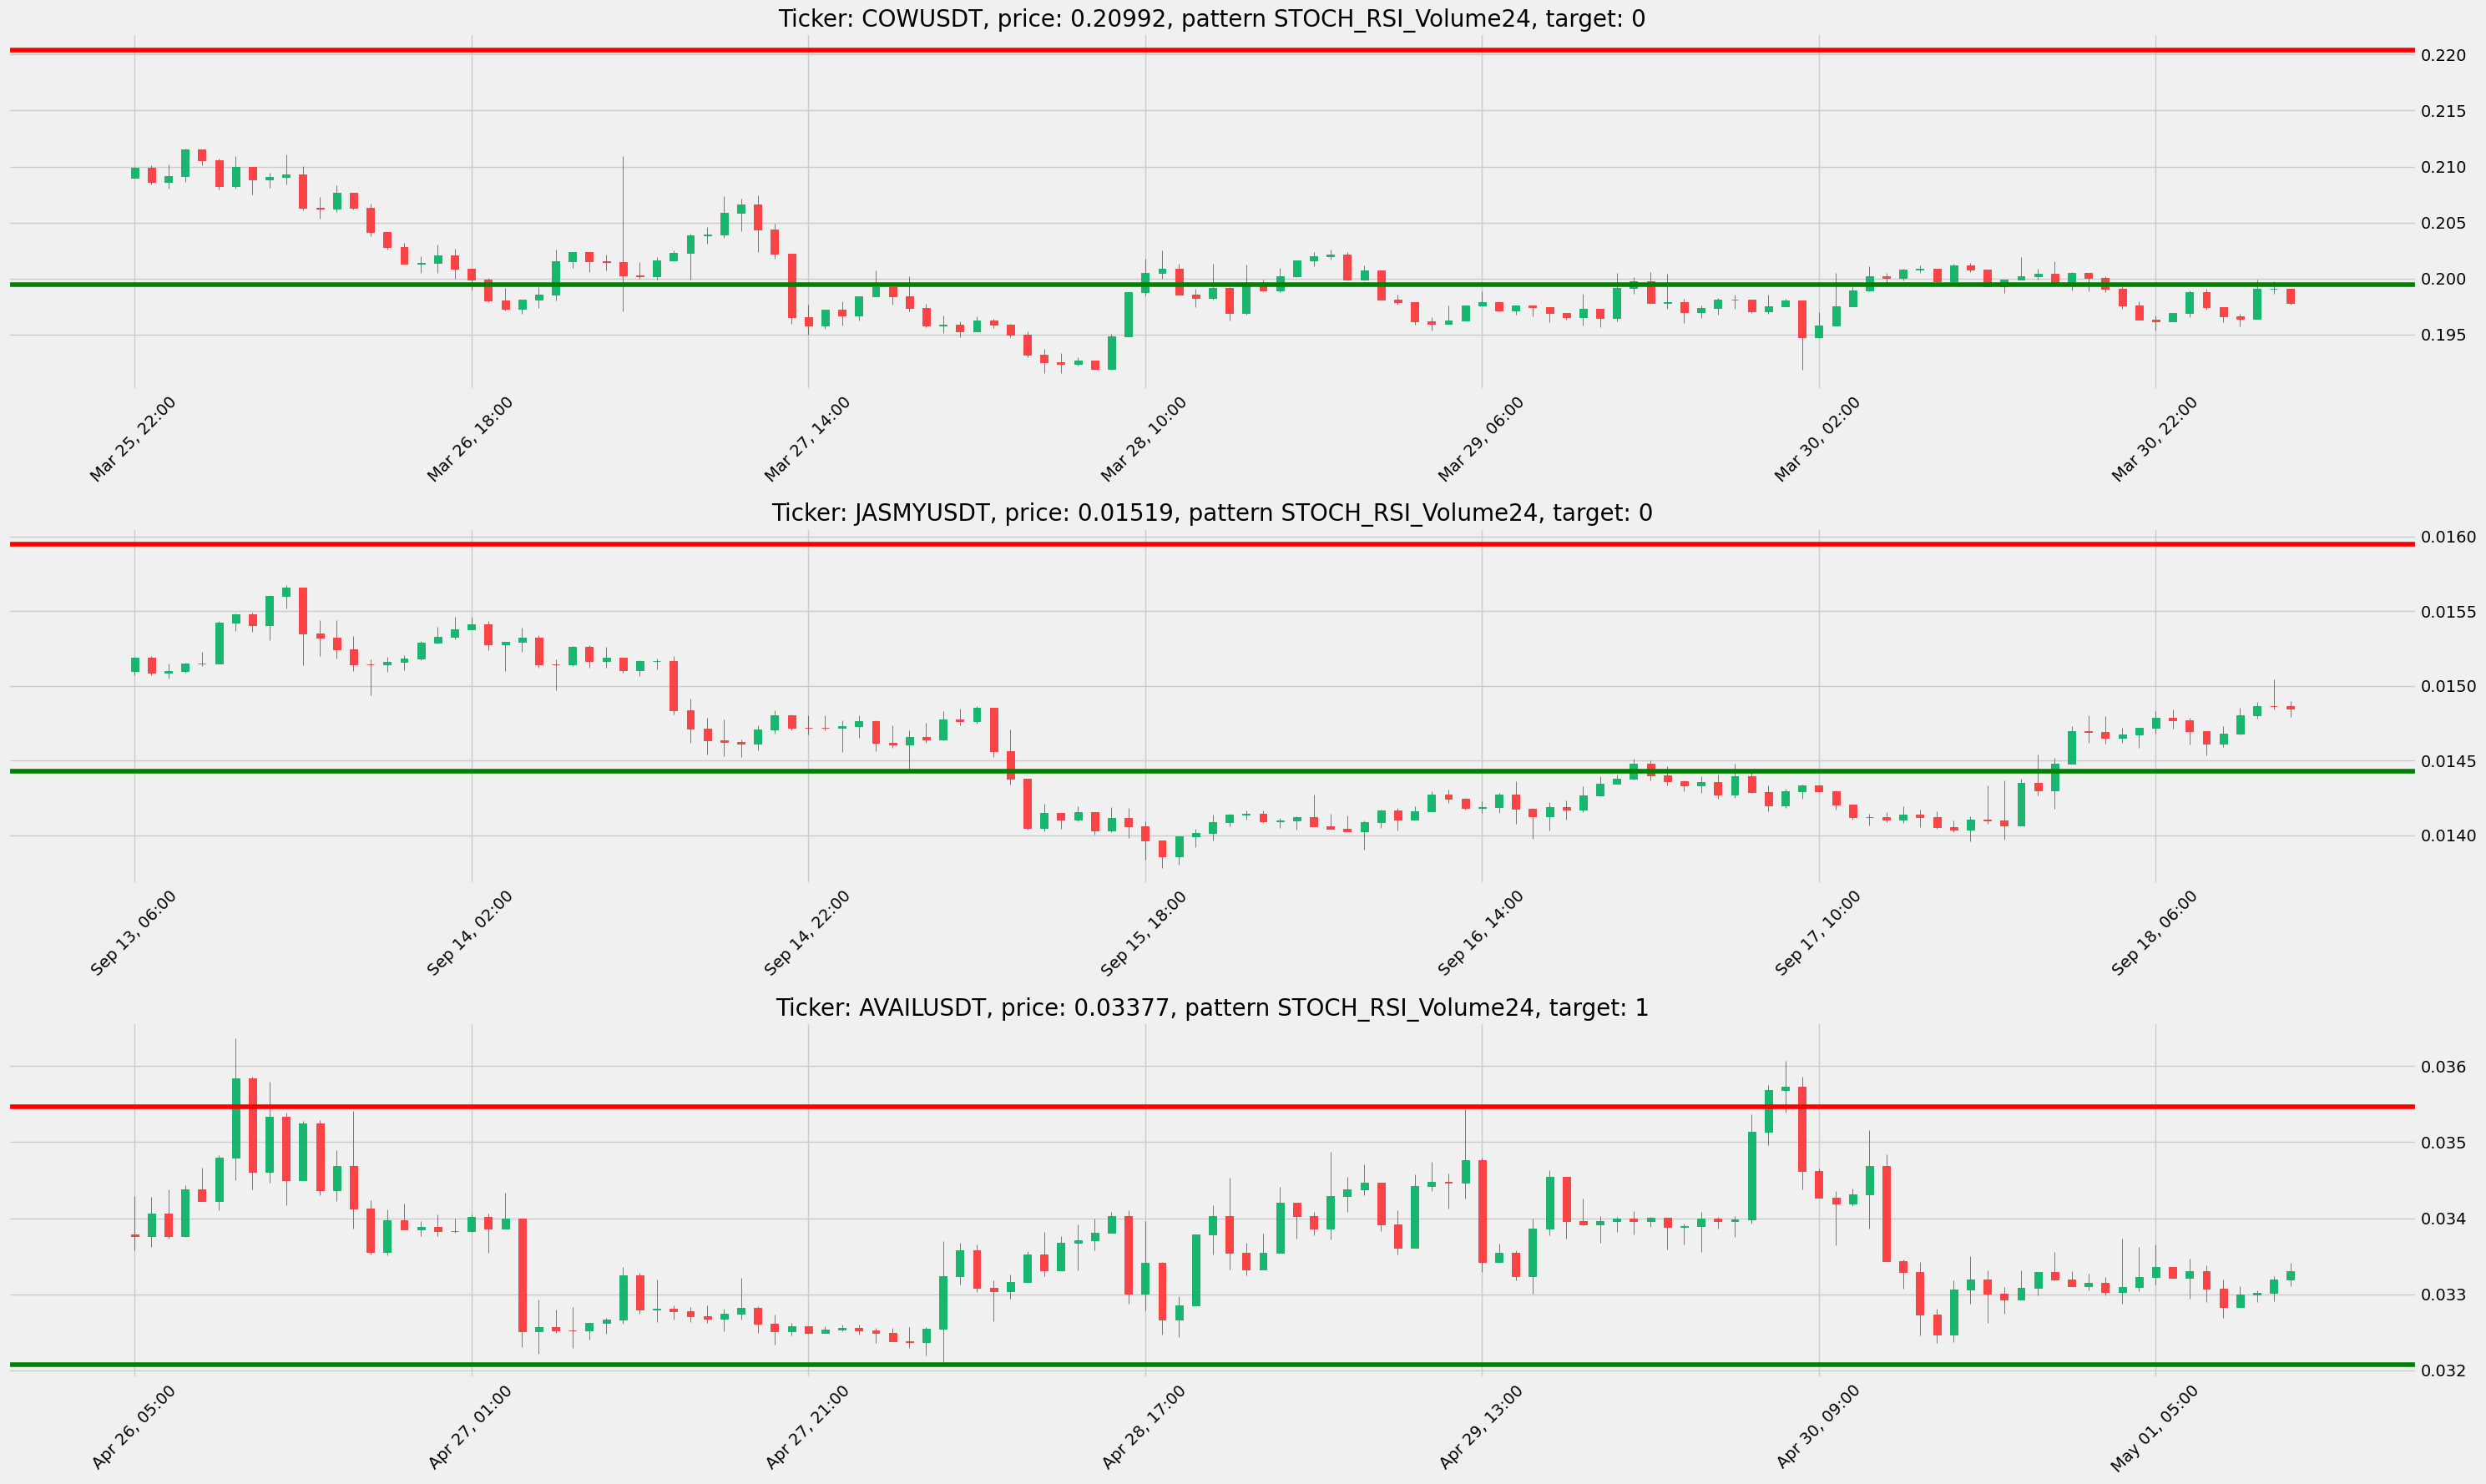

In [ ]:
if CFG.create_dataset:
    plt_num = 3
    j = 1
    fig = plt.figure(figsize=(30, 6 * plt_num))

    buy_idxs = train_sell.index
    test_sell = train_sell.sample(plt_num, axis=0)

    for i, row in test_sell.iterrows():
        ticker = row["ticker"]
        time = row["time"]
        target = row["target"]
        ttype = row["ttype"]
        pattern = row["pattern"]

        df_1h, _ = get_file(ticker)
        df_1h = df_1h[(df_1h["time"] >= time) & (df_1h["time"] <= time + timedelta(hours=CFG.target_offset))]
        
        ohlc = df_1h[["time", "open", "high", "low", "close", "volume"]].set_index("time")
        
        price = df_1h.iloc[0]["close"]
        high_price = price * CFG.target_high_ratio
        low_price = price * CFG.target_low_ratio

        ax = fig.add_subplot(plt_num, 1, j)
        mpf.plot(ohlc, type="candle", warn_too_much_data=1001, style="yahoo", ylabel="", tz_localize=True, ax=ax)
        
        if ttype == "buy":
            ax.axhline(high_price, color="g")
            ax.axhline(low_price, color="r")
        else:
            ax.axhline(high_price, color="r")
            ax.axhline(low_price, color="g")
        ax.set_title(f"Ticker: {ticker}, price: {price}, pattern {pattern}, target: {target}", fontsize=20)
        j += 1
        
    fig.tight_layout()

### Show the last signals

In [ ]:
train_df.loc[train_df["pattern"] == "STOCH_RSI_Volume24", ["time", "ticker", "ttype", "pattern"]].sort_values("time").reset_index(drop=True).tail(20)

,time,ticker,ttype,pattern
113983,2026-06-03 04:00:00,ERAUSDT,buy,STOCH_RSI_Volume24
113984,2026-06-03 04:00:00,APRUSDT,sell,STOCH_RSI_Volume24
113985,2026-06-03 04:00:00,APTUSDT,buy,STOCH_RSI_Volume24
113986,2026-06-03 04:00:00,ATHUSDT,buy,STOCH_RSI_Volume24
113987,2026-06-03 04:00:00,BERAUSDT,buy,STOCH_RSI_Volume24
113988,2026-06-03 04:00:00,CAKEUSDT,buy,STOCH_RSI_Volume24
113989,2026-06-03 04:00:00,KERNELUSDT,buy,STOCH_RSI_Volume24
113990,2026-06-03 04:00:00,XCNUSDT,buy,STOCH_RSI_Volume24
113991,2026-06-03 04:00:00,MIRAUSDT,buy,STOCH_RSI_Volume24
113992,2026-06-03 05:00:00,JITOSOLUSDT,buy,STOCH_RSI_Volume24


# Save train data

In [ ]:
train_df.to_pickle("data/train_df.pkl")

### Verify the saved artifact round-trips correctly

In [ ]:
saved = pd.read_pickle("data/train_df.pkl")

combined = pd.concat([train_buy, train_sell], ignore_index=True)
dropped = int((combined["time"] == combined["time"].max()).sum())

assert len(saved) == len(combined) - dropped, \
    f"saved rows ({len(saved)}) != expected ({len(combined) - dropped})"
assert set(saved["ttype"].unique()) == {"buy", "sell"}, \
    f"saved file is missing a ttype: {set(saved['ttype'].unique())}"
print(f"Saved artifact OK: {len(saved)} rows, ttypes={set(saved['ttype'].unique())}")

Saved artifact OK: 114003 rows, ttypes={'buy', 'sell'}


# Remove the tickers that are not presented in the train dataset

In [ ]:
all_tickers = glob.glob("data/tickers/*.pkl") # !

buy_stat_df = pd.read_pickle("data/signal_stat/buy_stat_1h.pkl")
sell_stat_df = pd.read_pickle("data/signal_stat/sell_stat_1h.pkl")
stat_tickers = set(buy_stat_df["ticker"].unique()).union(set(sell_stat_df["ticker"].unique()))

tickers_to_del = [t for t in all_tickers if t[13:-7] not in stat_tickers]

# for ticker in tickers_to_del:
#     os.remove(ticker)